# Mentoría PDIS — Notebook 01
# Análisis, Visualización y Curación de Datos
## Olaroz + Hombre Muerto

Este notebook implementa las **tres primeras etapas** del pipeline:

1. **Análisis de Datos**
2. **Visualización de Datos**
3. **Curación + Feature Engineering + construcción de Data Marts**

La salida no es un único dataset arbitrario, sino **tres Data Marts comparables**, cada uno diseñado para responder una pregunta distinta antes de pasar a Aprendizaje No Supervisado y Supervisado.

---

## Filosofía metodológica

La unidad original es un **píxel muestreado dentro de un polígono etiquetado**.

Por eso existen tres niveles que no deben confundirse:

```text
sample_id   -> observación/píxel
polygon_id  -> unidad espacial de etiquetado
salar       -> dominio geográfico
```

La regla más importante de todo el proyecto es:

> **Nunca dividir píxeles del mismo `polygon_id` entre train y test.**

En los notebooks posteriores, `polygon_id` será la variable de agrupación para evitar **spatial leakage**.

---

# Salidas

Este notebook genera:

```text
outputs_datamarts/
├── data_mart_01_fisico_completo.parquet
├── data_mart_01_fisico_completo.csv
│
├── data_mart_02_indices_compacto.parquet
├── data_mart_02_indices_compacto.csv
│
├── data_mart_03_contexto_espacial.parquet
├── data_mart_03_contexto_espacial.csv
│
├── data_master_curado.parquet
├── data_master_curado.csv
│
├── reporte_calidad.csv
├── reporte_poligonos.csv
├── reporte_clases.csv
├── reporte_domain_shift_global.csv
├── reporte_domain_shift_por_clase.csv
├── reporte_domain_classifier.csv
├── diccionario_variables.csv
└── metadata_datamarts.json
```

---

# Los tres Data Marts

## Data Mart 01 — Físico completo

Contiene:

- bandas espectrales no redundantes;
- índices espectrales originales;
- features físicas derivadas;
- metadata necesaria para auditoría.

Es el **Data Mart recomendado como baseline principal**.

---

## Data Mart 02 — Índices compacto

Contiene:

- índices espectrales;
- ratios y contrastes derivados;
- pocas variables de brillo/contexto espectral.

Busca responder:

> ¿Podemos obtener buen desempeño y mejor transferencia utilizando una representación más compacta?

---

## Data Mart 03 — Contexto espacial

Contiene lo del Data Mart 01 más variables espaciales **relativas al dominio**, no coordenadas absolutas.

Se utiliza como **ablation experiment**:

> ¿Agregar contexto espacial mejora la clasificación o hace que el modelo dependa demasiado del salar?

No debe asumirse que este Data Mart transferirá mejor. Precisamente queremos medirlo.

---

# Transferencia de dominio

Antes de entrenar clasificadores ambientales, este notebook estudia la tendencia de transferencia mediante:

- diferencias de medias estandarizadas (SMD);
- análisis condicionado por clase;
- PCA exploratorio;
- un **clasificador de dominio** que intenta distinguir Olaroz de Hombre Muerto.

Interpretación del clasificador de dominio:

```text
ROC-AUC ~ 0.50 -> los dominios son difíciles de distinguir
ROC-AUC alto   -> existe domain shift detectable
```

Esto **no demuestra** transferencia, pero permite anticipar cuán difícil puede ser.

# 0. Dependencias

```bash
pip install pandas numpy matplotlib scikit-learn pyarrow
```

El notebook usa deliberadamente un stack pequeño y estándar.

No se usa `seaborn`, y toda la lógica importante está escrita en funciones simples para que sea fácil de enseñar, auditar y modificar.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)


# Reproducibilidad

RANDOM_STATE = 42

# Configuración de Pandas

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)

# 1. Configuración del proyecto

In [2]:
# ARCHIVOS DE ENTRADA

# Cambiá estas rutas solamente si tus archivos están en otra carpeta.
PARQUET_PATH = Path("dataset_salares_ml.parquet")
CSV_PATH = Path("dataset_salares_ml.csv")
METADATA_PATH = Path("dataset_salares_ml_metadata.json")

# CARPETA DE SALIDA

OUTPUT_DIR = Path("outputs_datamarts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# VARIABLES PRINCIPALES DEL CONTRATO DE DATOS

ID_COL = "sample_id"
GROUP_COL = "polygon_id"
DOMAIN_COL = "salar"
TARGET_COL = "clase"

# Metadata: columnas útiles para auditoría, pero que no forman
# parte del conjunto espectral básico de predictores.


BASE_METADATA_COLS = [
    "sample_id",
    "polygon_id",
    "salar",
    "clase",
    "confianza",
    "x",
    "y",
    "lon",
    "lat",
    "qa_valid_fraction",
]

# Parámetros de diagnóstico

IQR_FACTOR = 3.0

# Para gráficos muy grandes usamos una muestra reproducible.
MAX_PLOT_SAMPLES = 12000

# 2. Carga robusta

In [3]:
def load_dataset(
    parquet_path: Path,
    csv_path: Path,
) -> pd.DataFrame:
    '''
    Carga primero Parquet por eficiencia y preservación de tipos.

    Si Parquet no está disponible o falta pyarrow, usa CSV
    automáticamente.
    '''

    if parquet_path.exists():
        try:
            df = pd.read_parquet(parquet_path)

            print(
                f"✓ Dataset cargado desde Parquet: "
                f"{parquet_path.resolve()}"
            )

            return df

        except Exception as exc:
            print("No fue posible leer el Parquet.")
            print("Motivo:", exc)
            print("Se intentará cargar el CSV.\n")

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        print(
            f"✓ Dataset cargado desde CSV: "
            f"{csv_path.resolve()}"
        )

        return df

    raise FileNotFoundError(
        "No se encontró ni el Parquet ni el CSV."
    )


df_raw = load_dataset(
    parquet_path=PARQUET_PATH,
    csv_path=CSV_PATH,
)

print("\nShape:", df_raw.shape)

display(df_raw.head())

✓ Dataset cargado desde Parquet: C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\dataset_salares_ml.parquet

Shape: (38621, 35)


,sample_id,polygon_id,salar,clase,confianza,x,y,lon,lat,spec_B04,spec_B03,spec_B02,spec_B05,spec_B06,spec_B07,spec_B08,spec_B8A,spec_B11,spec_B12,feat_B04,feat_B03,feat_B02,feat_B05,feat_B06,feat_B07,feat_B08,feat_B8A,feat_B11,feat_B12,feat_NDVI,feat_NDWI,feat_MNDWI,feat_NDMI,feat_BSI,qa_valid_fraction
0,OLA_AGU_001_00001,OLA_AGU_001,olaroz,agua_humedad,3,729660.0,7381660.0,-66.748317,-23.659492,4423.0,6470.5,5596.5,3590.0,1462.0,1368.0,1351.0,1183.5,1081.0,1080.0,4423.0,6470.5,5596.5,3590.0,1462.0,1368.0,1351.0,1183.5,1081.0,1080.0,-0.532040,0.654542,0.713699,0.111020,-0.115930,1.0
1,OLA_AGU_001_00002,OLA_AGU_001,olaroz,agua_humedad,3,729700.0,7381140.0,-66.747845,-23.664180,3728.5,6366.0,5318.0,2920.5,1248.0,1167.0,1156.0,1075.5,1053.5,1051.5,3728.5,6366.0,5318.0,2920.5,1248.0,1167.0,1156.0,1075.5,1053.5,1051.5,-0.526666,0.692635,0.716019,0.046391,-0.150320,1.0
2,OLA_AGU_001_00003,OLA_AGU_001,olaroz,agua_humedad,3,729840.0,7381720.0,-66.746563,-23.658925,3664.0,6025.5,4968.0,2873.0,1227.0,1157.0,1153.0,1061.0,1045.5,1059.5,3664.0,6025.5,4968.0,2873.0,1227.0,1157.0,1153.0,1061.0,1045.5,1059.5,-0.521279,0.678763,0.704285,0.048897,-0.130326,1.0
3,OLA_AGU_001_00004,OLA_AGU_001,olaroz,agua_humedad,3,729540.0,7381600.0,-66.749484,-23.660051,4437.0,6401.0,5518.0,3603.0,1488.5,1373.0,1355.5,1129.0,1053.0,1041.0,4437.0,6401.0,5518.0,3603.0,1488.5,1373.0,1355.5,1129.0,1053.0,1041.0,-0.531981,0.650487,0.717467,0.125597,-0.111902,1.0
4,OLA_AGU_001_00005,OLA_AGU_001,olaroz,agua_humedad,3,729300.0,7381060.0,-66.751752,-23.664959,4587.5,6702.0,5809.0,3718.5,1544.0,1403.5,1381.5,1139.5,1057.5,1050.0,4587.5,6702.0,5809.0,3718.5,1544.0,1403.5,1381.5,1139.5,1057.5,1050.0,-0.537108,0.658193,0.727431,0.132841,-0.120408,1.0


In [4]:
# Metadata original del proceso de muestreo, si está disponible.

if METADATA_PATH.exists():

    with open(
        METADATA_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        source_metadata = json.load(file)

    print("✓ Metadata encontrada")

    display(
        pd.Series(
            source_metadata,
            name="valor",
        ).to_frame()
    )

else:

    source_metadata = {}

    print(
        "No se encontró metadata JSON. "
        "El análisis puede continuar."
    )

✓ Metadata encontrada


,valor
dataset,dataset_salares_ml
salares,"[hombre_muerto, olaroz]"
classes,"[agua_humedad, salina, suelo_desnudo, suelo_ro..."
n_samples,38621
n_polygons,48
n_features,25
features,"[spec_B04, spec_B03, spec_B02, spec_B05, spec_..."
max_pixels_per_polygon,1000
min_valid_fraction,0.7
crs_training_polygons,EPSG:32719


# ETAPA I — ANÁLISIS DE DATOS

Antes de visualizar o transformar, auditamos la estructura.

La idea es que cualquier modificación posterior pueda justificarse.

## 3. Contrato y roles de variables

In [5]:
# Validación mínima


required_columns = {
    ID_COL,
    GROUP_COL,
    DOMAIN_COL,
    TARGET_COL,
}

missing_columns = (
    required_columns
    - set(df_raw.columns)
)

if missing_columns:
    raise ValueError(
        f"Faltan columnas obligatorias: "
        f"{sorted(missing_columns)}"
    )

print("✓ Contrato mínimo satisfecho")


# Metadata realmente presente


metadata_cols = [
    col
    for col in BASE_METADATA_COLS
    if col in df_raw.columns
]


# Features candidatas originales

raw_feature_cols = [
    col
    for col in df_raw.columns
    if col not in metadata_cols
]

print("\nMetadata:")
print(metadata_cols)

print("\nFeatures candidatas originales:")
print(raw_feature_cols)

✓ Contrato mínimo satisfecho

Metadata:
['sample_id', 'polygon_id', 'salar', 'clase', 'confianza', 'x', 'y', 'lon', 'lat', 'qa_valid_fraction']

Features candidatas originales:
['spec_B04', 'spec_B03', 'spec_B02', 'spec_B05', 'spec_B06', 'spec_B07', 'spec_B08', 'spec_B8A', 'spec_B11', 'spec_B12', 'feat_B04', 'feat_B03', 'feat_B02', 'feat_B05', 'feat_B06', 'feat_B07', 'feat_B08', 'feat_B8A', 'feat_B11', 'feat_B12', 'feat_NDVI', 'feat_NDWI', 'feat_MNDWI', 'feat_NDMI', 'feat_BSI']


## 4. Auditoría general

In [6]:
def count_infinite_values(
    data: pd.DataFrame,
) -> int:
    '''
    Cuenta infinitos solamente en columnas numéricas.
    '''

    numeric = data.select_dtypes(
        include=np.number
    )

    return int(
        np.isinf(
            numeric.to_numpy()
        ).sum()
    )


audit_general = pd.DataFrame(
    {
        "muestras": [
            len(df_raw)
        ],
        "poligonos": [
            df_raw[GROUP_COL].nunique()
        ],
        "dominios": [
            df_raw[DOMAIN_COL].nunique()
        ],
        "clases": [
            df_raw[TARGET_COL].nunique()
        ],
        "columnas_totales": [
            df_raw.shape[1]
        ],
        "features_candidatas": [
            len(raw_feature_cols)
        ],
        "sample_id_duplicados": [
            int(
                df_raw[ID_COL]
                .duplicated()
                .sum()
            )
        ],
        "nulos_totales": [
            int(
                df_raw
                .isna()
                .sum()
                .sum()
            )
        ],
        "infinitos_totales": [
            count_infinite_values(
                df_raw
            )
        ],
    }
)

display(audit_general)

,muestras,poligonos,dominios,clases,columnas_totales,features_candidatas,sample_id_duplicados,nulos_totales,infinitos_totales
0,38621,48,2,4,35,25,0,0,0


In [7]:
print("Dominios:")
print(
    sorted(
        df_raw[DOMAIN_COL]
        .astype(str)
        .unique()
    )
)

print("\nClases:")
print(
    sorted(
        df_raw[TARGET_COL]
        .astype(str)
        .unique()
    )
)

print("\nTipos de datos:")
display(
    df_raw.dtypes.to_frame(
        "dtype"
    )
)

Dominios:
['hombre_muerto', 'olaroz']

Clases:
['agua_humedad', 'salina', 'suelo_desnudo', 'suelo_rocoso']

Tipos de datos:


,dtype
sample_id,str
polygon_id,str
salar,str
clase,str
confianza,int64
x,float64
y,float64
lon,float64
lat,float64
spec_B04,float32


## 5. Balance real: polígonos vs píxeles

In [8]:
# Balance por dominio y clase

class_report_raw = (
    df_raw
    .groupby(
        [
            DOMAIN_COL,
            TARGET_COL,
        ]
    )
    .agg(
        n_samples=(
            ID_COL,
            "size",
        ),
        n_polygons=(
            GROUP_COL,
            "nunique",
        ),
    )
    .reset_index()
)

display(class_report_raw)

,salar,clase,n_samples,n_polygons
0,hombre_muerto,agua_humedad,3184,6
1,hombre_muerto,salina,2047,6
2,hombre_muerto,suelo_desnudo,6000,6
3,hombre_muerto,suelo_rocoso,6000,6
4,olaroz,agua_humedad,5173,6
5,olaroz,salina,4217,6
6,olaroz,suelo_desnudo,6000,6
7,olaroz,suelo_rocoso,6000,6


In [9]:
# Cantidad de muestras que aporta cada polígono
polygon_report_raw = (
    df_raw
    .groupby(
        [
            GROUP_COL,
            DOMAIN_COL,
            TARGET_COL,
        ],
        as_index=False,
    )
    .agg(
        n_samples=(
            ID_COL,
            "size",
        )
    )
)

if "confianza" in df_raw.columns:

    confidence_by_polygon = (
        df_raw
        .groupby(
            GROUP_COL
        )["confianza"]
        .first()
    )

    polygon_report_raw[
        "confianza"
    ] = (
        polygon_report_raw[
            GROUP_COL
        ]
        .map(
            confidence_by_polygon
        )
    )

display(
    polygon_report_raw
    .sort_values(
        "n_samples",
        ascending=False,
    )
)

,polygon_id,salar,clase,n_samples,confianza
6,HOM_DES_001,hombre_muerto,suelo_desnudo,1000,3
7,HOM_DES_002,hombre_muerto,suelo_desnudo,1000,3
13,HOM_ROC_002,hombre_muerto,suelo_rocoso,1000,3
12,HOM_ROC_001,hombre_muerto,suelo_rocoso,1000,3
11,HOM_DES_006,hombre_muerto,suelo_desnudo,1000,3
10,HOM_DES_005,hombre_muerto,suelo_desnudo,1000,3
9,HOM_DES_004,hombre_muerto,suelo_desnudo,1000,3
8,HOM_DES_003,hombre_muerto,suelo_desnudo,1000,3
14,HOM_ROC_003,hombre_muerto,suelo_rocoso,1000,3
15,HOM_ROC_004,hombre_muerto,suelo_rocoso,1000,3


### Punto metodológico importante

Aunque haya el mismo número de polígonos por clase, no necesariamente hay el mismo número de píxeles.

Por eso crearemos después un:

```text
sample_weight_equal_polygon
```

para que cada polígono pueda tener aproximadamente la misma influencia durante el entrenamiento supervisado, si así se desea.

## 6. QA y confianza del etiquetado

In [10]:
if "qa_valid_fraction" in df_raw.columns:

    print("QA valid fraction:")

    display(
        df_raw[
            "qa_valid_fraction"
        ]
        .describe()
        .to_frame()
    )

else:

    print(
        "No existe la columna "
        "'qa_valid_fraction'."
    )


if "confianza" in df_raw.columns:

    print("\nConfianza de etiquetado:")

    display(
        df_raw[
            "confianza"
        ]
        .value_counts(
            dropna=False
        )
        .sort_index()
        .to_frame("n_samples")
    )

QA valid fraction:


,qa_valid_fraction
count,38621.000000
mean,0.979510
std,0.054728
min,0.833333
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000



Confianza de etiquetado:


,n_samples
confianza,
3,38621


## 7. Estadística descriptiva de features

In [11]:
feature_stats = (
    df_raw[
        raw_feature_cols
    ]
    .describe()
    .T
)

feature_stats[
    "n_unique"
] = [
    df_raw[col]
    .nunique(
        dropna=True
    )
    for col
    in feature_stats.index
]

feature_stats[
    "missing"
] = [
    int(
        df_raw[col]
        .isna()
        .sum()
    )
    for col
    in feature_stats.index
]

display(feature_stats)

,count,mean,std,min,25%,50%,75%,max,n_unique,missing
spec_B04,38621.0,4033.197266,1923.089233,1716.500000,2844.500000,3168.500000,4138.250000,9709.000000,10557,0
spec_B03,38621.0,4067.561523,2205.754150,1382.500000,2356.000000,2737.000000,6276.500000,9097.000000,10518,0
spec_B02,38621.0,3664.476318,2218.138916,1263.500000,1966.500000,2326.500000,5772.500000,8692.000000,10549,0
spec_B05,38621.0,3992.500244,1979.475586,1527.500000,2880.000000,3154.500000,3762.000000,9933.000000,9630,0
spec_B06,38621.0,3681.812012,2178.034424,1037.000000,2731.500000,3121.500000,3707.500000,9851.000000,10369,0
spec_B07,38621.0,3694.778320,2193.840088,1013.500000,2769.500000,3162.000000,3762.000000,9906.000000,10203,0
spec_B08,38621.0,3703.522217,2216.225830,1061.500000,2789.500000,3154.500000,3784.500000,9926.000000,10184,0
spec_B8A,38621.0,3632.239014,2217.860352,961.500000,2768.500000,3128.000000,3780.250000,9905.000000,9600,0
spec_B11,38621.0,3383.647217,1377.545532,1018.000000,3011.000000,3668.250000,4082.500000,8167.000000,9433,0
spec_B12,38621.0,2930.652832,1036.235596,1003.500000,2729.000000,3221.750000,3588.500000,6792.000000,7123,0


## 8. Validación física básica de índices

In [12]:
# Los índices normalizados normalmente deberían permanecer
# aproximadamente dentro del rango [-1, 1].
#
# No eliminamos automáticamente valores fuera de rango:
# primero los reportamos.

index_cols_original = [
    col
    for col in raw_feature_cols
    if col.startswith("feat_")
    and col
    in {
        "feat_NDVI",
        "feat_NDWI",
        "feat_MNDWI",
        "feat_NDMI",
        "feat_BSI",
    }
]

index_range_report = []

for col in index_cols_original:

    values = df_raw[col]

    index_range_report.append(
        {
            "feature": col,
            "min": values.min(),
            "max": values.max(),
            "n_below_minus_1": int(
                (values < -1).sum()
            ),
            "n_above_plus_1": int(
                (values > 1).sum()
            ),
        }
    )

index_range_report = pd.DataFrame(
    index_range_report
)

display(index_range_report)

,feature,min,max,n_below_minus_1,n_above_plus_1
0,feat_NDVI,-0.547127,0.198639,0,0
1,feat_NDWI,-0.318907,0.726559,0,0
2,feat_MNDWI,-0.359392,0.773454,0,0
3,feat_NDMI,-0.208319,0.500053,0,0
4,feat_BSI,-0.402436,0.231068,0,0


# ETAPA II — VISUALIZACIÓN DE DATOS

Las visualizaciones se diseñan para responder preguntas concretas, no para decorar el análisis.

## 9. Distribución de muestras por dominio y clase

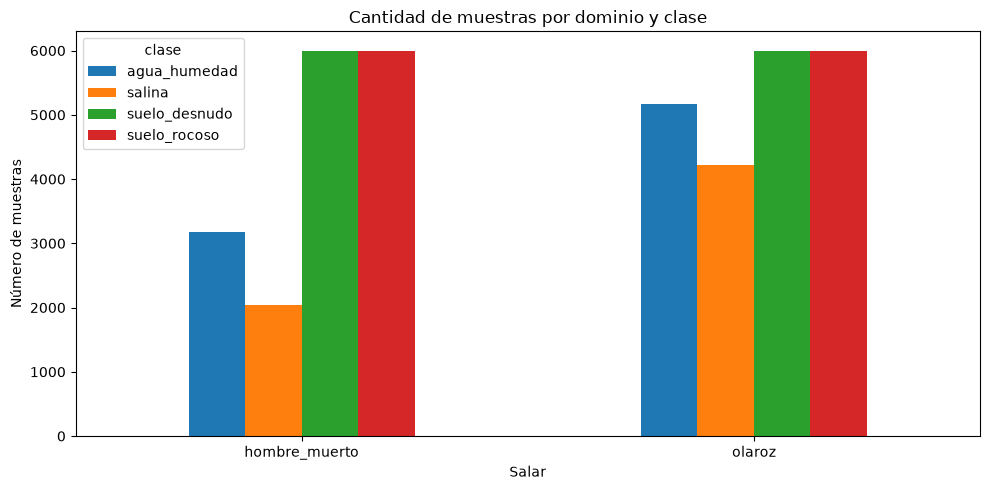

In [13]:
plot_counts = (
    df_raw
    .groupby(
        [
            DOMAIN_COL,
            TARGET_COL,
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

ax = plot_counts.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Cantidad de muestras por dominio y clase"
)

ax.set_xlabel(
    "Salar"
)

ax.set_ylabel(
    "Número de muestras"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

## 10. Muestras aportadas por cada polígono

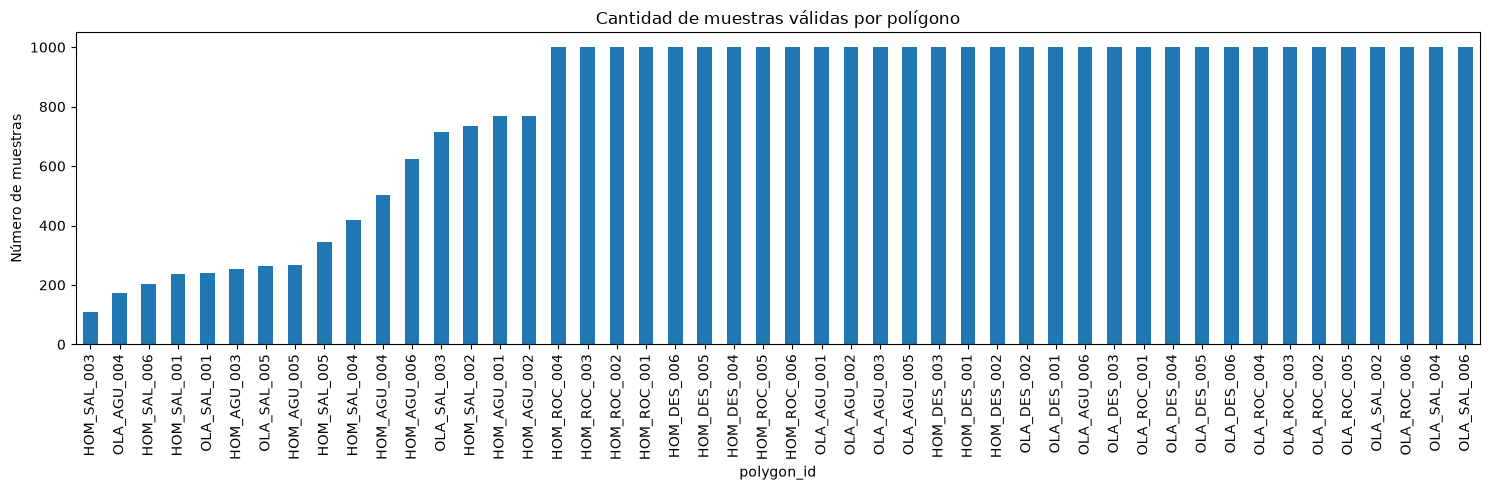

In [14]:
ax = (
    polygon_report_raw
    .sort_values(
        "n_samples"
    )
    .plot(
        x=GROUP_COL,
        y="n_samples",
        kind="bar",
        figsize=(15, 5),
        legend=False,
    )
)

ax.set_title(
    "Cantidad de muestras válidas por polígono"
)

ax.set_xlabel(
    "polygon_id"
)

ax.set_ylabel(
    "Número de muestras"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

## 11. Distribución del control de calidad

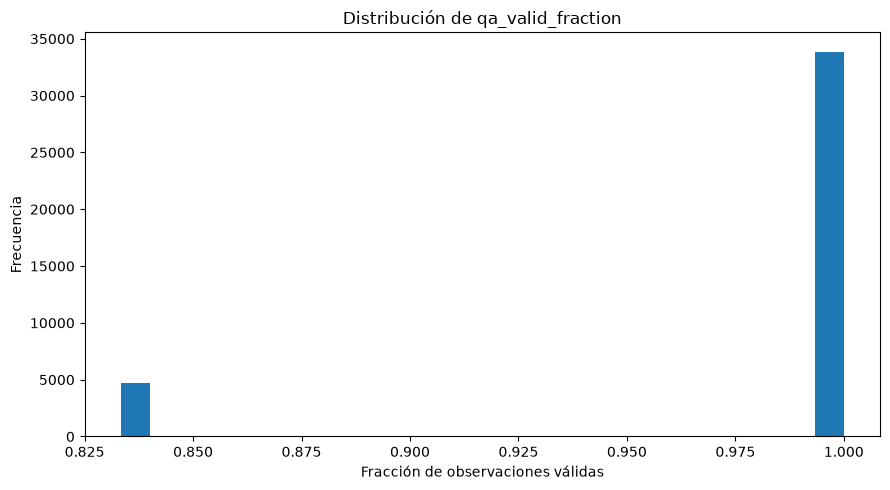

In [15]:
if "qa_valid_fraction" in df_raw.columns:

    plt.figure(
        figsize=(9, 5)
    )

    plt.hist(
        df_raw[
            "qa_valid_fraction"
        ].dropna(),
        bins=25,
    )

    plt.title(
        "Distribución de qa_valid_fraction"
    )

    plt.xlabel(
        "Fracción de observaciones válidas"
    )

    plt.ylabel(
        "Frecuencia"
    )

    plt.tight_layout()
    plt.show()

## 12. Índices espectrales por clase

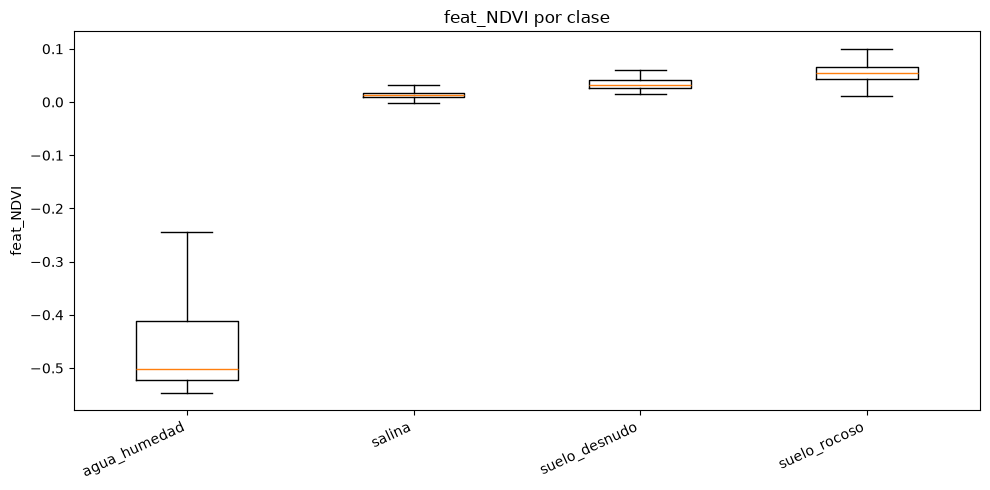

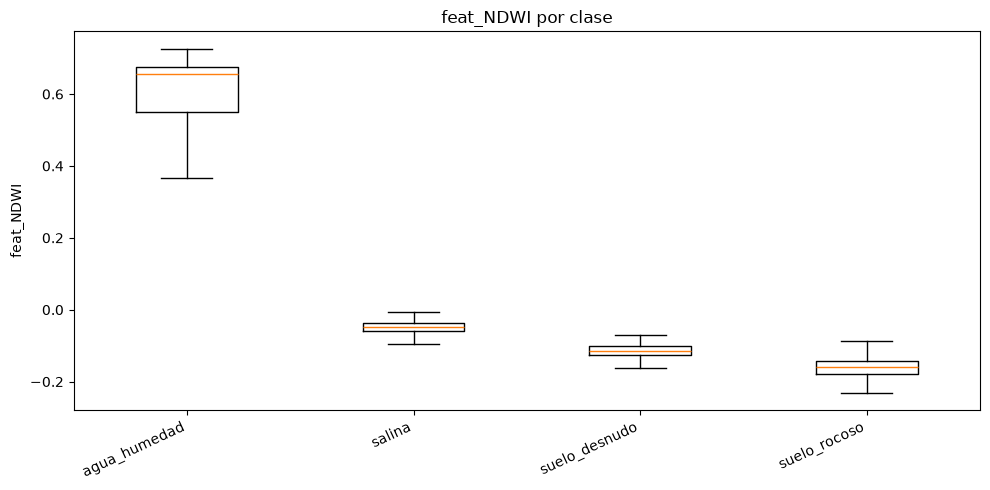

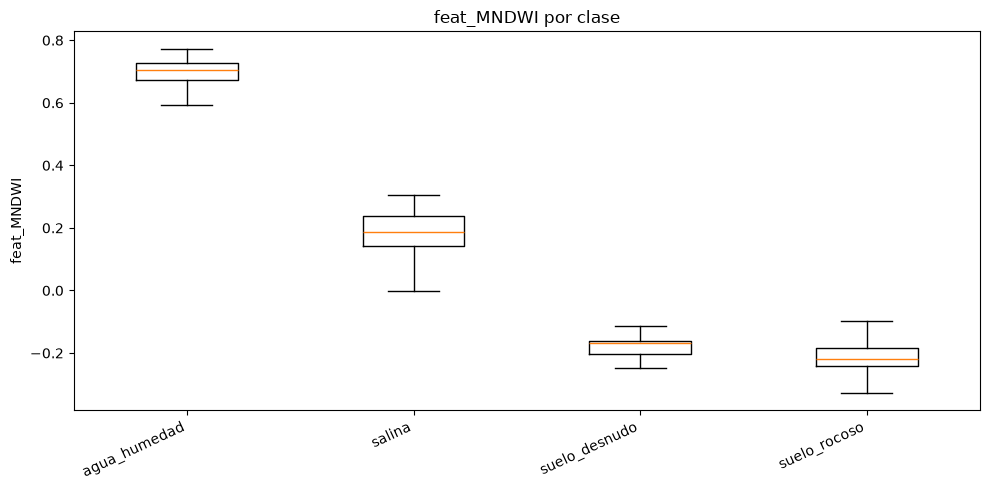

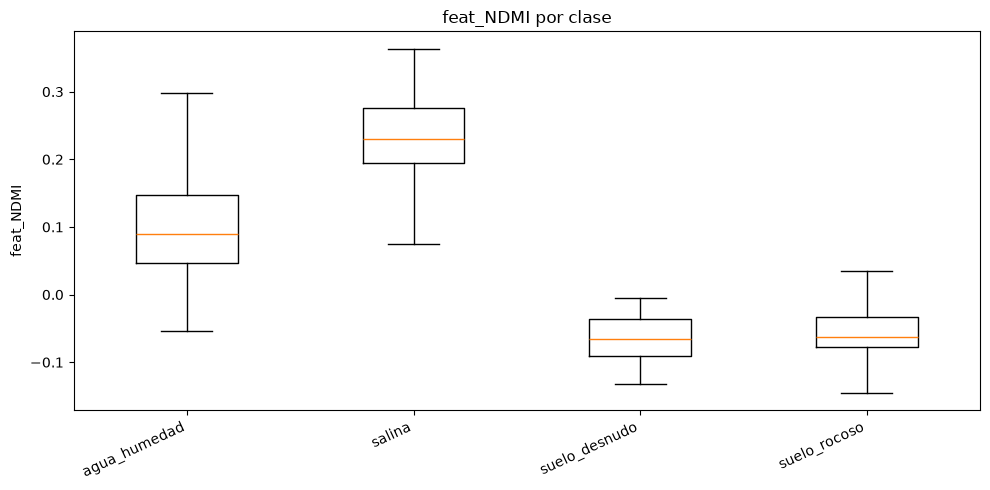

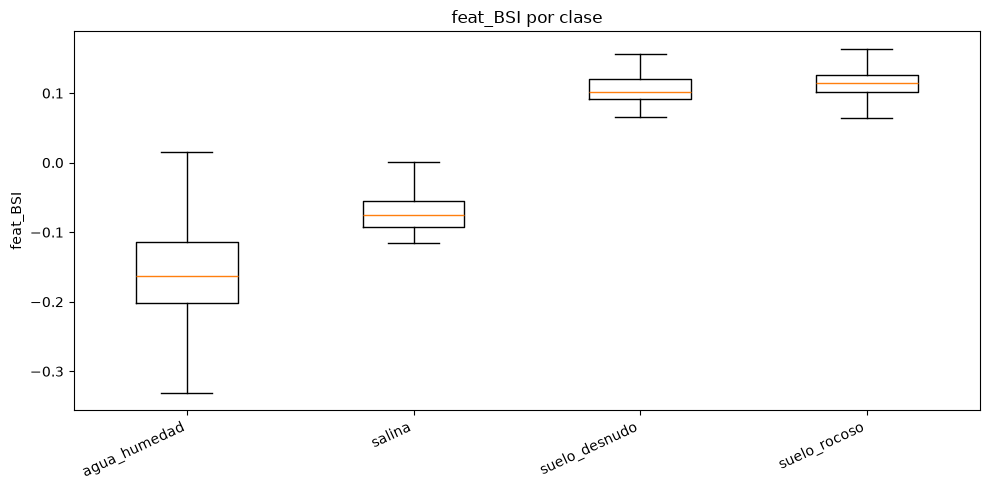

In [16]:
for feature in index_cols_original:

    classes = sorted(
        df_raw[
            TARGET_COL
        ].unique()
    )

    values = [
        df_raw.loc[
            df_raw[
                TARGET_COL
            ] == clase,
            feature,
        ]
        .dropna()
        .to_numpy()

        for clase
        in classes
    ]

    plt.figure(
        figsize=(10, 5)
    )

    plt.boxplot(
        values,
        tick_labels=classes,
        showfliers=False,
    )

    plt.title(
        f"{feature} por clase"
    )

    plt.ylabel(
        feature
    )

    plt.xticks(
        rotation=25,
        ha="right",
    )

    plt.tight_layout()
    plt.show()

## 13. Índices espectrales por dominio

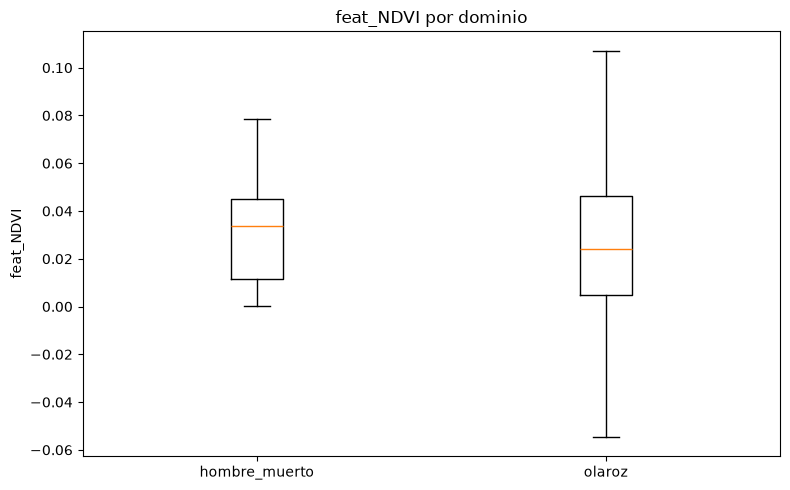

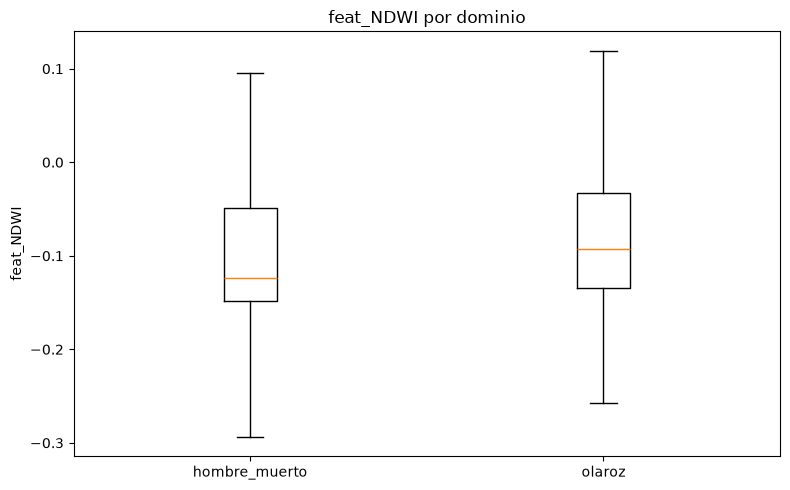

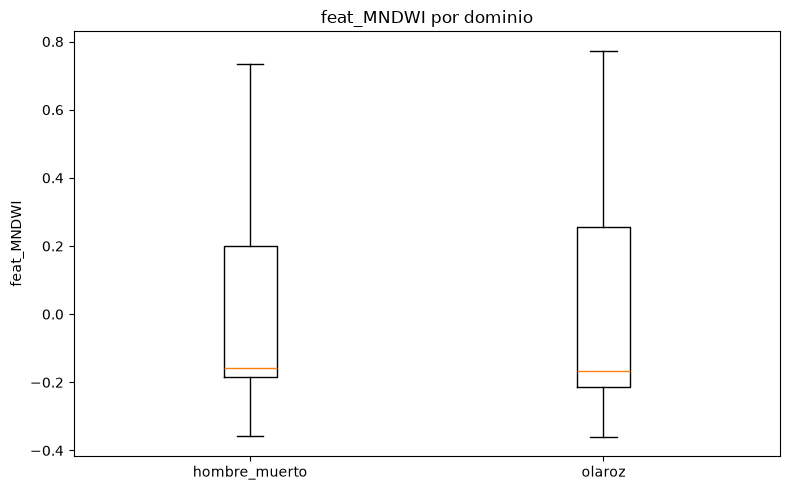

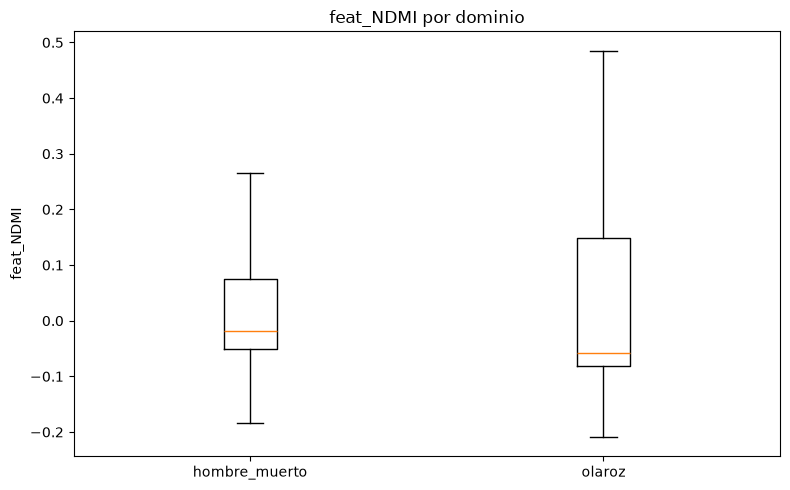

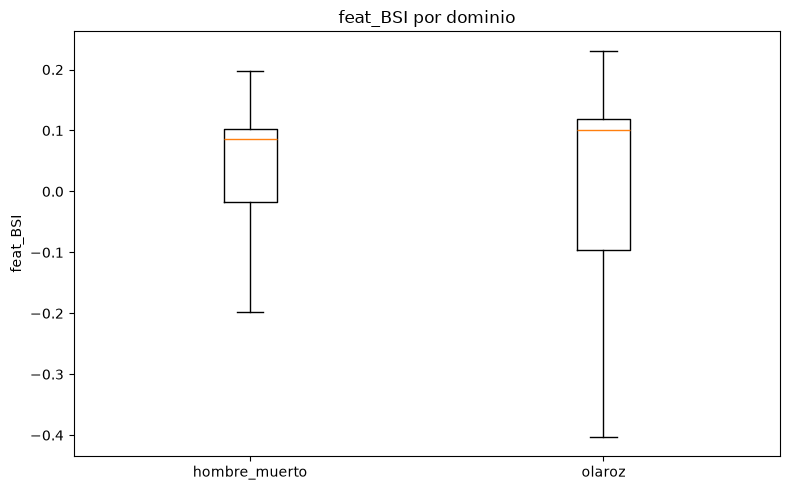

In [17]:
for feature in index_cols_original:

    domains = sorted(
        df_raw[
            DOMAIN_COL
        ].unique()
    )

    values = [
        df_raw.loc[
            df_raw[
                DOMAIN_COL
            ] == domain,
            feature,
        ]
        .dropna()
        .to_numpy()

        for domain
        in domains
    ]

    plt.figure(
        figsize=(8, 5)
    )

    plt.boxplot(
        values,
        tick_labels=domains,
        showfliers=False,
    )

    plt.title(
        f"{feature} por dominio"
    )

    plt.ylabel(
        feature
    )

    plt.tight_layout()
    plt.show()

## 14. Mapa simple de las muestras

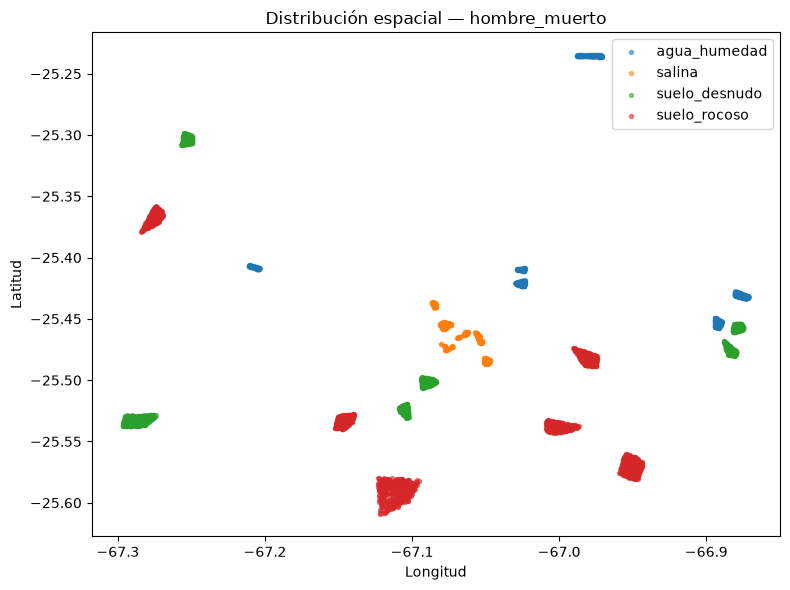

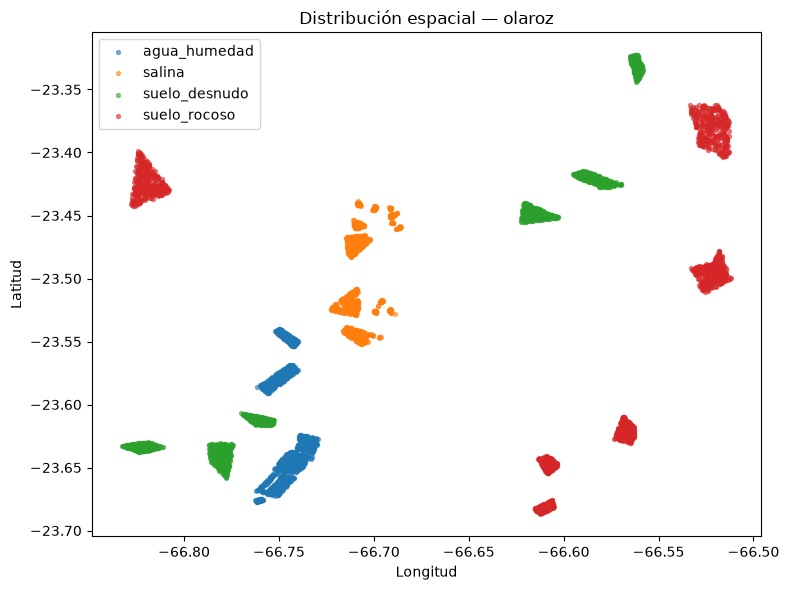

In [18]:
# Visualización espacial usando lon/lat.
#
# No usamos estas coordenadas todavía como predictors.
# Solo sirven para verificar la estructura espacial.


if {
    "lon",
    "lat",
}.issubset(
    df_raw.columns
):

    plot_df = (
        df_raw
        .sample(
            n=min(
                MAX_PLOT_SAMPLES,
                len(df_raw),
            ),
            random_state=RANDOM_STATE,
        )
    )

    for domain in sorted(
        plot_df[
            DOMAIN_COL
        ].unique()
    ):

        domain_df = plot_df[
            plot_df[
                DOMAIN_COL
            ] == domain
        ]

        plt.figure(
            figsize=(8, 6)
        )

        for clase in sorted(
            domain_df[
                TARGET_COL
            ].unique()
        ):

            subset = domain_df[
                domain_df[
                    TARGET_COL
                ] == clase
            ]

            plt.scatter(
                subset["lon"],
                subset["lat"],
                s=8,
                alpha=0.55,
                label=clase,
            )

        plt.title(
            f"Distribución espacial — {domain}"
        )

        plt.xlabel(
            "Longitud"
        )

        plt.ylabel(
            "Latitud"
        )

        plt.legend()

        plt.tight_layout()
        plt.show()

## 15. Correlación entre features originales

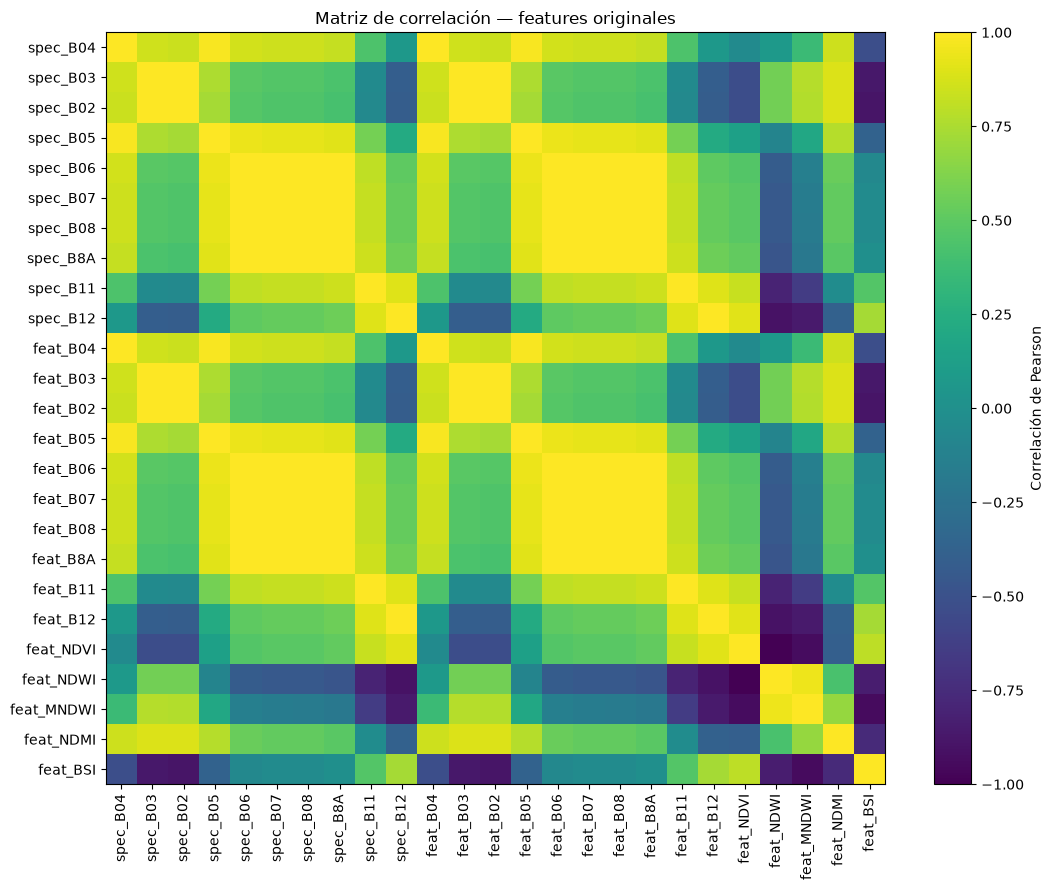

In [19]:
# La correlación alta no implica automáticamente eliminación.
#
# En sensores multiespectrales es normal que varias bandas estén
# correlacionadas.

corr = (
    df_raw[
        raw_feature_cols
    ]
    .corr()
)

plt.figure(
    figsize=(11, 9)
)

image = plt.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

plt.colorbar(
    image,
    label="Correlación de Pearson",
)

plt.xticks(
    range(
        len(corr.columns)
    ),
    corr.columns,
    rotation=90,
)

plt.yticks(
    range(
        len(corr.columns)
    ),
    corr.columns,
)

plt.title(
    "Matriz de correlación — features originales"
)

plt.tight_layout()
plt.show()

# 16. Tendencia inicial de transferencia de dominio

Esta parte busca medir cuánto se parecen o diferencian Olaroz y Hombre Muerto **antes de entrenar el clasificador ambiental**.

## 16.1 Standardized Mean Difference (SMD)

In [20]:
def standardized_mean_difference(
    a: pd.Series,
    b: pd.Series,
) -> float:
    '''
    Diferencia de medias expresada en desviaciones estándar
    combinadas.

    Un valor absoluto pequeño indica distribuciones con medias
    más similares.

    No es una métrica de clasificación.
    '''

    a = (
        a
        .dropna()
        .astype(float)
    )

    b = (
        b
        .dropna()
        .astype(float)
    )

    pooled_variance = (
        a.var(
            ddof=1
        )
        +
        b.var(
            ddof=1
        )
    ) / 2

    if (
        not np.isfinite(
            pooled_variance
        )
        or pooled_variance <= 0
    ):
        return 0.0

    return (
        a.mean()
        - b.mean()
    ) / np.sqrt(
        pooled_variance
    )

In [21]:
domains = sorted(
    df_raw[
        DOMAIN_COL
    ].unique()
)

if len(domains) != 2:
    raise ValueError(
        "Este análisis de transferencia "
        "espera exactamente dos dominios."
    )

DOMAIN_A, DOMAIN_B = domains

print(
    "Dominio A:",
    DOMAIN_A,
)

print(
    "Dominio B:",
    DOMAIN_B,
)

Dominio A: hombre_muerto
Dominio B: olaroz


In [22]:
def build_smd_report(
    data: pd.DataFrame,
    feature_columns: list[str],
    domain_a: str,
    domain_b: str,
    class_column: str | None = None,
) -> pd.DataFrame:
    '''
    Construye un reporte SMD global o condicionado por clase.
    '''

    rows = []

    if class_column is None:
        scopes = [
            ("ALL", data)
        ]
    else:
        scopes = [
            (
                str(clase),
                data[
                    data[
                        class_column
                    ] == clase
                ],
            )
            for clase
            in sorted(
                data[
                    class_column
                ].unique()
            )
        ]

    for scope_name, subset in scopes:

        for feature in feature_columns:

            values_a = subset.loc[
                subset[
                    DOMAIN_COL
                ] == domain_a,
                feature,
            ]

            values_b = subset.loc[
                subset[
                    DOMAIN_COL
                ] == domain_b,
                feature,
            ]

            smd = (
                standardized_mean_difference(
                    values_a,
                    values_b,
                )
            )

            rows.append(
                {
                    "scope": scope_name,
                    "feature": feature,
                    "mean_domain_a": (
                        values_a.mean()
                    ),
                    "mean_domain_b": (
                        values_b.mean()
                    ),
                    "smd": smd,
                    "abs_smd": abs(
                        smd
                    ),
                }
            )

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            [
                "scope",
                "abs_smd",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )


smd_global_raw = (
    build_smd_report(
        data=df_raw,
        feature_columns=raw_feature_cols,
        domain_a=DOMAIN_A,
        domain_b=DOMAIN_B,
    )
)

smd_by_class_raw = (
    build_smd_report(
        data=df_raw,
        feature_columns=raw_feature_cols,
        domain_a=DOMAIN_A,
        domain_b=DOMAIN_B,
        class_column=TARGET_COL,
    )
)

print("SMD global:")
display(
    smd_global_raw.head(20)
)

print("\nSMD condicionado por clase:")
display(
    smd_by_class_raw.head(30)
)

SMD global:


,scope,feature,mean_domain_a,mean_domain_b,smd,abs_smd
0,ALL,spec_B02,3211.818604,4029.120850,-0.380196,0.380196
1,ALL,feat_B02,3211.818604,4029.120850,-0.380196,0.380196
2,ALL,spec_B03,3629.014893,4420.838867,-0.369864,0.369864
3,ALL,feat_B03,3629.014893,4420.838867,-0.369864,0.369864
4,ALL,feat_BSI,0.042113,0.007881,0.287307,0.287307
5,ALL,feat_NDWI,-0.002299,0.066958,-0.231250,0.231250
6,ALL,spec_B12,3055.200439,2830.321777,0.217894,0.217894
7,ALL,feat_B12,3055.200439,2830.321777,0.217894,0.217894
8,ALL,spec_B04,3829.980957,4196.900879,-0.194246,0.194246
9,ALL,feat_B04,3829.980957,4196.900879,-0.194246,0.194246



SMD condicionado por clase:


,scope,feature,mean_domain_a,mean_domain_b,smd,abs_smd
0,agua_humedad,spec_B03,5134.320801,6544.834961,-1.217340,1.217340
1,agua_humedad,feat_B03,5134.320801,6544.834961,-1.217340,1.217340
2,agua_humedad,feat_BSI,-0.098403,-0.188349,1.186886,1.186886
3,agua_humedad,spec_B02,4625.427246,6243.812988,-1.177010,1.177010
4,agua_humedad,feat_B02,4625.427246,6243.812988,-1.177010,1.177010
5,agua_humedad,feat_NDWI,0.552835,0.627103,-0.618220,0.618220
6,agua_humedad,feat_MNDWI,0.624542,0.691097,-0.583516,0.583516
7,agua_humedad,spec_B04,3715.277344,4099.967285,-0.475900,0.475900
8,agua_humedad,feat_B04,3715.277344,4099.967285,-0.475900,0.475900
9,agua_humedad,spec_B8A,1211.133423,1333.929443,-0.271439,0.271439


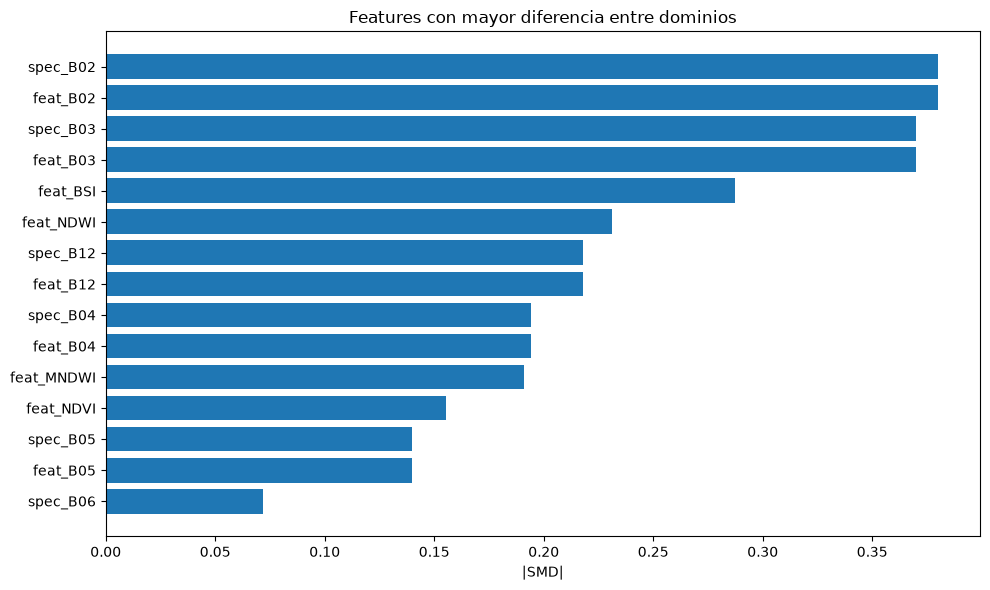

In [23]:
top_smd = (
    smd_global_raw
    .sort_values(
        "abs_smd",
        ascending=False,
    )
    .head(15)
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_smd[
        "feature"
    ][::-1],
    top_smd[
        "abs_smd"
    ][::-1],
)

plt.title(
    "Features con mayor diferencia entre dominios"
)

plt.xlabel(
    "|SMD|"
)

plt.tight_layout()
plt.show()

## 16.2 PCA exploratorio por dominio y clase

In [24]:
# PCA solo para visualización exploratoria.
# No se exportan PC1/PC2 como predictors por defecto.


pca_features = [
    col
    for col in raw_feature_cols
    if (
        df_raw[col]
        .nunique(
            dropna=True
        )
        > 1
    )
]

X_pca = (
    df_raw[
        pca_features
    ]
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
    .dropna()
)

pca_index = (
    X_pca.index
)

pca_scaler = (
    StandardScaler()
)

X_pca_scaled = (
    pca_scaler
    .fit_transform(
        X_pca
    )
)

pca_model = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

pca_values = (
    pca_model
    .fit_transform(
        X_pca_scaled
    )
)

pca_df = pd.DataFrame(
    {
        "PC1": (
            pca_values[
                :,
                0
            ]
        ),
        "PC2": (
            pca_values[
                :,
                1
            ]
        ),
        "salar": (
            df_raw.loc[
                pca_index,
                DOMAIN_COL,
            ]
            .to_numpy()
        ),
        "clase": (
            df_raw.loc[
                pca_index,
                TARGET_COL,
            ]
            .to_numpy()
        ),
    }
)

print(
    "Varianza explicada:",
    pca_model.explained_variance_ratio_,
)

Varianza explicada: [0.59501904 0.38005573]


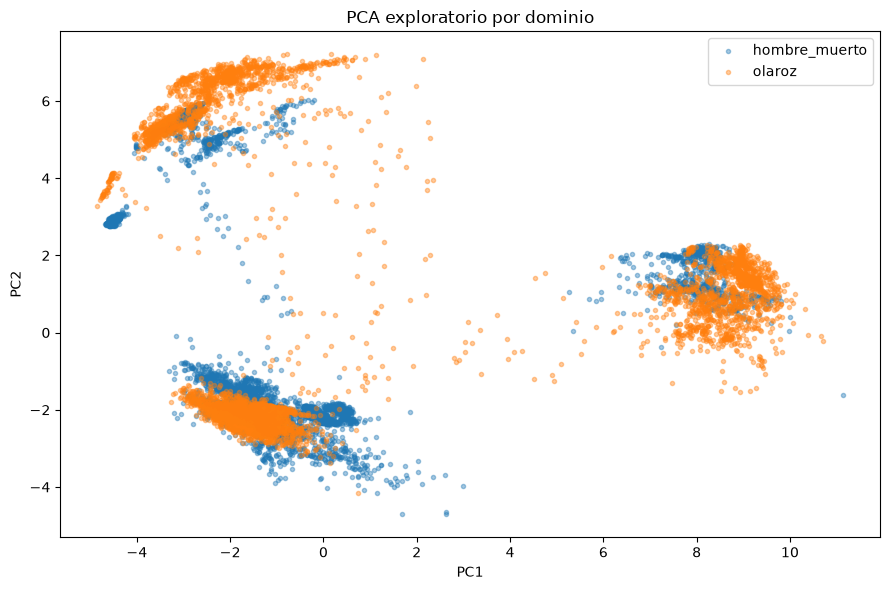

In [25]:
plot_pca_df = (
    pca_df
    .sample(
        n=min(
            MAX_PLOT_SAMPLES,
            len(pca_df),
        ),
        random_state=RANDOM_STATE,
    )
)

plt.figure(
    figsize=(9, 6)
)

for domain in sorted(
    plot_pca_df[
        "salar"
    ].unique()
):

    subset = (
        plot_pca_df[
            plot_pca_df[
                "salar"
            ] == domain
        ]
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=9,
        alpha=0.40,
        label=domain,
    )

plt.title(
    "PCA exploratorio por dominio"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.tight_layout()
plt.show()

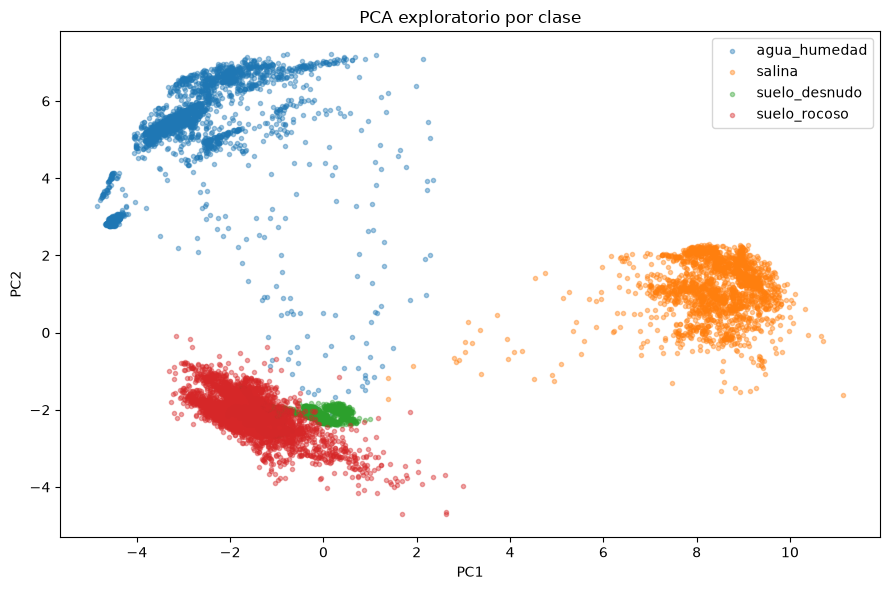

In [26]:
plt.figure(
    figsize=(9, 6)
)

for clase in sorted(
    plot_pca_df[
        "clase"
    ].unique()
):

    subset = (
        plot_pca_df[
            plot_pca_df[
                "clase"
            ] == clase
        ]
    )

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=9,
        alpha=0.40,
        label=clase,
    )

plt.title(
    "PCA exploratorio por clase"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.tight_layout()
plt.show()

# ETAPA III — CURACIÓN Y FEATURE ENGINEERING

En esta etapa se construye una representación más limpia sin alterar arbitrariamente la señal ambiental.

## 17. Copia de trabajo y normalización

In [27]:
# Nunca modificamos df_raw directamente.
df = df_raw.copy()


# Normalización de strings


for col in [
    ID_COL,
    GROUP_COL,
    DOMAIN_COL,
    TARGET_COL,
]:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )


df[DOMAIN_COL] = (
    df[DOMAIN_COL]
    .str.lower()
)

df[TARGET_COL] = (
    df[TARGET_COL]
    .str.lower()
)


# sample_id debe identificar una fila de forma única

before = len(df)

df = (
    df
    .drop_duplicates(
        subset=[
            ID_COL
        ],
        keep="first",
    )
    .copy()
)

print(
    "Duplicados sample_id eliminados:",
    before - len(df),
)

Duplicados sample_id eliminados: 0


## 18. Infinitos y valores faltantes

In [28]:
numeric_cols = (
    df
    .select_dtypes(
        include=np.number
    )
    .columns
)

df[
    numeric_cols
] = (
    df[
        numeric_cols
    ]
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
)

print(
    "Nulos luego de convertir infinitos:",
    int(
        df
        .isna()
        .sum()
        .sum()
    ),
)

Nulos luego de convertir infinitos: 0


## 19. Detectar features constantes

In [29]:
current_metadata_cols = [
    col
    for col in BASE_METADATA_COLS
    if col in df.columns
]

candidate_features = [
    col
    for col in df.columns
    if col not in current_metadata_cols
]

constant_features = [
    col
    for col in candidate_features
    if (
        df[col]
        .nunique(
            dropna=True
        )
        <= 1
    )
]

print(
    "Features constantes:",
    constant_features,
)

if constant_features:

    df = df.drop(
        columns=constant_features
    )

Features constantes: []


## 20. Eliminar redundancia exacta entre bandas

In [30]:
def find_exact_duplicate_columns(
    data: pd.DataFrame,
    columns: list[str],
) -> list[tuple[str, str]]:
    '''
    Busca columnas numéricamente idénticas.
    '''

    duplicate_pairs = []

    for i, col_a in enumerate(
        columns
    ):

        values_a = (
            data[
                col_a
            ]
            .to_numpy()
        )

        for col_b in columns[
            i + 1:
        ]:

            values_b = (
                data[
                    col_b
                ]
                .to_numpy()
            )

            if np.array_equal(
                values_a,
                values_b,
                equal_nan=True,
            ):

                duplicate_pairs.append(
                    (
                        col_a,
                        col_b,
                    )
                )

    return duplicate_pairs


candidate_features = [
    col
    for col in df.columns
    if col not in current_metadata_cols
]

exact_duplicate_pairs = (
    find_exact_duplicate_columns(
        data=df,
        columns=candidate_features,
    )
)

duplicate_report = pd.DataFrame(
    exact_duplicate_pairs,
    columns=[
        "feature_a",
        "feature_b",
    ],
)

display(
    duplicate_report
)

,feature_a,feature_b
0,spec_B04,feat_B04
1,spec_B03,feat_B03
2,spec_B02,feat_B02
3,spec_B05,feat_B05
4,spec_B06,feat_B06
5,spec_B07,feat_B07
6,spec_B08,feat_B08
7,spec_B8A,feat_B8A
8,spec_B11,feat_B11
9,spec_B12,feat_B12


In [31]:
# Política:
#
# Si spec_Bxx y feat_Bxx son idénticas:
# conservamos spec_Bxx y eliminamos feat_Bxx.
#
# Los índices feat_NDVI, feat_NDWI, etc. se conservan.


features_to_drop = []

for col_a, col_b in exact_duplicate_pairs:

    if (
        col_a.startswith("spec_")
        and col_b.startswith("feat_")
    ):
        features_to_drop.append(
            col_b
        )

    elif (
        col_b.startswith("spec_")
        and col_a.startswith("feat_")
    ):
        features_to_drop.append(
            col_a
        )

    else:
        # Si ninguna tiene prioridad semántica,
        # conservamos la primera.
        features_to_drop.append(
            col_b
        )


features_to_drop = sorted(
    set(
        features_to_drop
    )
)

print(
    "Features redundantes eliminadas:"
)

print(
    features_to_drop
)

if features_to_drop:

    df = df.drop(
        columns=features_to_drop
    )

Features redundantes eliminadas:
['feat_B02', 'feat_B03', 'feat_B04', 'feat_B05', 'feat_B06', 'feat_B07', 'feat_B08', 'feat_B11', 'feat_B12', 'feat_B8A']


## 21. Limpieza conservadora de NaN

In [32]:
# Solamente eliminamos filas que tengan NaN en features
# necesarias.
#
# No imputamos reflectancias o índices sin una justificación
# física.


current_feature_cols = [
    col
    for col in df.columns
    if col not in current_metadata_cols
]

before = len(df)

df = (
    df
    .dropna(
        subset=current_feature_cols
    )
    .copy()
)

print(
    "Filas eliminadas por NaN en features:",
    before - len(df),
)

Filas eliminadas por NaN en features: 0


# 22. Feature Engineering físico e interpretable

No buscamos generar cientos de features.

Buscamos un conjunto pequeño, legible y razonable para:

- clasificación;
- clustering;
- comparación entre dominios.

In [33]:
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    eps: float = 1e-8,
) -> pd.Series:
    '''
    División robusta.

    Los denominadores muy cercanos a cero se convierten
    temporalmente en NaN.
    '''

    denominator_safe = (
        denominator
        .where(
            denominator.abs()
            > eps,
            np.nan,
        )
    )

    return (
        numerator
        / denominator_safe
    )

In [34]:
# Verificamos que las bandas principales estén presentes.

required_spectral_bands = [
    "spec_B02",
    "spec_B03",
    "spec_B04",
    "spec_B05",
    "spec_B06",
    "spec_B07",
    "spec_B08",
    "spec_B8A",
    "spec_B11",
    "spec_B12",
]

missing_spectral_bands = [
    col
    for col
    in required_spectral_bands
    if col not in df.columns
]

if missing_spectral_bands:

    raise ValueError(
        "Faltan bandas necesarias para el "
        "feature engineering: "
        f"{missing_spectral_bands}"
    )


# Resúmenes espectrales por regiones del espectro


df[
    "eng_visible_mean"
] = (
    df[
        [
            "spec_B02",
            "spec_B03",
            "spec_B04",
        ]
    ]
    .mean(
        axis=1
    )
)


df[
    "eng_red_edge_mean"
] = (
    df[
        [
            "spec_B05",
            "spec_B06",
            "spec_B07",
        ]
    ]
    .mean(
        axis=1
    )
)


df[
    "eng_nir_mean"
] = (
    df[
        [
            "spec_B08",
            "spec_B8A",
        ]
    ]
    .mean(
        axis=1
    )
)


df[
    "eng_swir_mean"
] = (
    df[
        [
            "spec_B11",
            "spec_B12",
        ]
    ]
    .mean(
        axis=1
    )
)


# ------------------------------------------------------------
# 2. Brillo espectral global
# ------------------------------------------------------------

df[
    "eng_brightness"
] = (
    df[
        [
            "spec_B02",
            "spec_B03",
            "spec_B04",
            "spec_B08",
            "spec_B11",
            "spec_B12",
        ]
    ]
    .mean(
        axis=1
    )
)


# ------------------------------------------------------------
# 3. Ratios interpretables
# ------------------------------------------------------------

df[
    "eng_red_green_ratio"
] = (
    safe_ratio(
        df["spec_B04"],
        df["spec_B03"],
    )
)


df[
    "eng_nir_red_ratio"
] = (
    safe_ratio(
        df["spec_B08"],
        df["spec_B04"],
    )
)


df[
    "eng_nir_swir_ratio"
] = (
    safe_ratio(
        df["eng_nir_mean"],
        df["eng_swir_mean"],
    )
)


df[
    "eng_swir_ratio"
] = (
    safe_ratio(
        df["spec_B11"],
        df["spec_B12"],
    )
)


df[
    "eng_rededge_nir_ratio"
] = (
    safe_ratio(
        df["eng_red_edge_mean"],
        df["eng_nir_mean"],
    )
)


# ------------------------------------------------------------
# 4. Contrastes normalizados
# ------------------------------------------------------------

df[
    "eng_nir_swir_contrast"
] = (
    (
        df["eng_nir_mean"]
        -
        df["eng_swir_mean"]
    )
    /
    (
        df["eng_nir_mean"]
        +
        df["eng_swir_mean"]
    )
    .replace(
        0,
        np.nan,
    )
)


df[
    "eng_visible_nir_contrast"
] = (
    (
        df["eng_nir_mean"]
        -
        df["eng_visible_mean"]
    )
    /
    (
        df["eng_nir_mean"]
        +
        df["eng_visible_mean"]
    )
    .replace(
        0,
        np.nan,
    )
)


print(
    "✓ Feature engineering espectral completado"
)

✓ Feature engineering espectral completado


## 23. Variables espaciales relativas

In [35]:
# IMPORTANTE
#
# Las coordenadas UTM o lon/lat absolutas separan fácilmente
# Olaroz de Hombre Muerto por ubicación.
#
# Para un experimento espacial razonable creamos variables
# RELATIVAS dentro de cada dominio.
#
# Estas variables forman parte solamente del Data Mart 03.

if {
    "x",
    "y",
}.issubset(
    df.columns
):

    domain_x_mean = (
        df
        .groupby(
            DOMAIN_COL
        )["x"]
        .transform(
            "mean"
        )
    )

    domain_y_mean = (
        df
        .groupby(
            DOMAIN_COL
        )["y"]
        .transform(
            "mean"
        )
    )

    domain_x_std = (
        df
        .groupby(
            DOMAIN_COL
        )["x"]
        .transform(
            "std"
        )
        .replace(
            0,
            np.nan,
        )
    )

    domain_y_std = (
        df
        .groupby(
            DOMAIN_COL
        )["y"]
        .transform(
            "std"
        )
        .replace(
            0,
            np.nan,
        )
    )

    # Posición normalizada dentro de cada salar.
    df[
        "spatial_x_domain_z"
    ] = (
        (
            df["x"]
            - domain_x_mean
        )
        / domain_x_std
    )

    df[
        "spatial_y_domain_z"
    ] = (
        (
            df["y"]
            - domain_y_mean
        )
        / domain_y_std
    )

    # Distancia relativa al centro del conjunto de muestras
    # del salar.
    df[
        "spatial_radius_domain"
    ] = np.sqrt(
        (
            df[
                "spatial_x_domain_z"
            ]
            ** 2
        )
        +
        (
            df[
                "spatial_y_domain_z"
            ]
            ** 2
        )
    )


    # --------------------------------------------------------
    # Posición relativa al centro del polígono.
    #
    # No usa polygon_id como predictor, pero describe la
    # ubicación local del píxel dentro de su región muestreada.
    # --------------------------------------------------------

    polygon_x_mean = (
        df
        .groupby(
            GROUP_COL
        )["x"]
        .transform(
            "mean"
        )
    )

    polygon_y_mean = (
        df
        .groupby(
            GROUP_COL
        )["y"]
        .transform(
            "mean"
        )
    )

    df[
        "spatial_dx_polygon"
    ] = (
        df["x"]
        - polygon_x_mean
    )

    df[
        "spatial_dy_polygon"
    ] = (
        df["y"]
        - polygon_y_mean
    )

    df[
        "spatial_radius_polygon"
    ] = np.sqrt(
        (
            df[
                "spatial_dx_polygon"
            ]
            ** 2
        )
        +
        (
            df[
                "spatial_dy_polygon"
            ]
            ** 2
        )
    )

    print(
        "✓ Variables espaciales relativas generadas"
    )

else:

    print(
        "No existen x/y. "
        "No se generaron variables espaciales."
    )

✓ Variables espaciales relativas generadas


## 24. QA derivado y peso por polígono

In [36]:
# Nivel descriptivo de QA

if "qa_valid_fraction" in df.columns:

    df[
        "qa_level"
    ] = pd.cut(
        df[
            "qa_valid_fraction"
        ],
        bins=[
            -np.inf,
            0.80,
            0.90,
            np.inf,
        ],
        labels=[
            "aceptable",
            "buena",
            "muy_buena",
        ],
    )


# Peso para igualar influencia entre polígonos.
#
# Si un polígono tiene 1000 píxeles y otro 200, el primero no
# debería necesariamente tener cinco veces más peso científico.
#
# El peso se normaliza para que la media sea aproximadamente 1.

polygon_sample_count = (
    df
    .groupby(
        GROUP_COL
    )[ID_COL]
    .transform(
        "size"
    )
)

raw_polygon_weight = (
    1.0
    / polygon_sample_count
)

df[
    "sample_weight_equal_polygon"
] = (
    raw_polygon_weight
    / raw_polygon_weight.mean()
)

print(
    "✓ Peso por polígono generado"
)

✓ Peso por polígono generado


## 25. Outliers: detectar, no borrar automáticamente

In [37]:
# En datos ambientales un valor extremo puede ser real.
#
# Marcamos candidatos, pero no los borramos automáticamente.


temporary_metadata = [
    col
    for col in BASE_METADATA_COLS
    if col in df.columns
]

temporary_metadata += [
    "qa_level",
    "sample_weight_equal_polygon",
]

temporary_features = [
    col
    for col in df.columns
    if col not in temporary_metadata
]

outlier_matrix = pd.DataFrame(
    False,
    index=df.index,
    columns=temporary_features,
)

for feature in temporary_features:

    q1 = (
        df[feature]
        .quantile(
            0.25
        )
    )

    q3 = (
        df[feature]
        .quantile(
            0.75
        )
    )

    iqr = (
        q3
        - q1
    )

    lower = (
        q1
        - IQR_FACTOR
        * iqr
    )

    upper = (
        q3
        + IQR_FACTOR
        * iqr
    )

    outlier_matrix[
        feature
    ] = (
        (
            df[feature]
            < lower
        )
        |
        (
            df[feature]
            > upper
        )
    )


df[
    "n_outlier_features"
] = (
    outlier_matrix
    .sum(
        axis=1
    )
)


df[
    "is_outlier_candidate"
] = (
    df[
        "n_outlier_features"
    ]
    >= 3
)


print(
    "Observaciones marcadas como "
    "candidatos multivariados:"
)

print(
    int(
        df[
            "is_outlier_candidate"
        ]
        .sum()
    )
)

Observaciones marcadas como candidatos multivariados:
14358


## 26. Limpieza final después del Feature Engineering

In [38]:
# Columnas creadas que deben ser numéricas y finitas.


engineered_spectral_cols = [
    col
    for col in df.columns
    if col.startswith(
        "eng_"
    )
]

engineered_spatial_cols = [
    col
    for col in df.columns
    if col.startswith(
        "spatial_"
    )
]

new_numeric_cols = (
    engineered_spectral_cols
    +
    engineered_spatial_cols
)

df[
    new_numeric_cols
] = (
    df[
        new_numeric_cols
    ]
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
)


before = len(df)

df = (
    df
    .dropna(
        subset=new_numeric_cols
    )
    .copy()
)

print(
    "Filas eliminadas por valores no finitos "
    "en variables derivadas:",
    before - len(df),
)

Filas eliminadas por valores no finitos en variables derivadas: 0


# 27. Definición de los tres Data Marts

La selección de features se hace explícita y auditable.

In [39]:
# Bandas espectrales originales conservadas


spectral_band_cols = [
    col
    for col in df.columns
    if col.startswith(
        "spec_"
    )
]


# Índices originales


spectral_index_cols = [
    col
    for col in df.columns
    if col
    in {
        "feat_NDVI",
        "feat_NDWI",
        "feat_MNDWI",
        "feat_NDMI",
        "feat_BSI",
    }
]


# Metadata común a los tres marts

common_metadata_cols = [
    col
    for col in [
        "sample_id",
        "polygon_id",
        "salar",
        "clase",
        "confianza",
        "x",
        "y",
        "lon",
        "lat",
        "qa_valid_fraction",
        "qa_level",
        "sample_weight_equal_polygon",
        "n_outlier_features",
        "is_outlier_candidate",
    ]
    if col in df.columns
]


# DATA MART 01
# Físico completo

dm1_features = (
    spectral_band_cols
    +
    spectral_index_cols
    +
    engineered_spectral_cols
)

dm1_features = list(
    dict.fromkeys(
        dm1_features
    )
)


# DATA MART 02
# Índices compacto
#
# Conservamos índices y features derivadas que resumen
# relaciones espectrales.

dm2_engineered_features = [
    col
    for col in [
        "eng_visible_mean",
        "eng_red_edge_mean",
        "eng_nir_mean",
        "eng_swir_mean",
        "eng_brightness",
        "eng_red_green_ratio",
        "eng_nir_red_ratio",
        "eng_nir_swir_ratio",
        "eng_swir_ratio",
        "eng_rededge_nir_ratio",
        "eng_nir_swir_contrast",
        "eng_visible_nir_contrast",
    ]
    if col in df.columns
]

dm2_features = (
    spectral_index_cols
    +
    dm2_engineered_features
)

dm2_features = list(
    dict.fromkeys(
        dm2_features
    )
)



# DATA MART 03
# Contexto espacial


dm3_features = (
    dm1_features
    +
    engineered_spatial_cols
)

dm3_features = list(
    dict.fromkeys(
        dm3_features
    )
)


print(
    "DM1 features:",
    len(dm1_features),
)

print(
    "DM2 features:",
    len(dm2_features),
)

print(
    "DM3 features:",
    len(dm3_features),
)

DM1 features: 27
DM2 features: 17
DM3 features: 33


In [40]:
# Construcción de los DataFrames finales.

data_mart_01 = (
    df[
        common_metadata_cols
        +
        dm1_features
    ]
    .copy()
)

data_mart_02 = (
    df[
        common_metadata_cols
        +
        dm2_features
    ]
    .copy()
)

data_mart_03 = (
    df[
        common_metadata_cols
        +
        dm3_features
    ]
    .copy()
)


print(
    "Data Mart 01:",
    data_mart_01.shape,
)

print(
    "Data Mart 02:",
    data_mart_02.shape,
)

print(
    "Data Mart 03:",
    data_mart_03.shape,
)

Data Mart 01: (38621, 41)
Data Mart 02: (38621, 31)
Data Mart 03: (38621, 47)


# 28. Diagnóstico avanzado de transferencia por Data Mart

Ahora hacemos dos análisis distintos:

1. **SMD** por feature.
2. **Domain Classifier**.

El Domain Classifier no usa `clase` como target.

Su target es:

```text
salar
```

La pregunta es:

> ¿Qué tan fácil es distinguir Olaroz de Hombre Muerto usando solamente las features del Data Mart?

Si un modelo distingue los dominios con AUC muy alta, hay señal clara de domain shift.

## 28.1 Función para clasificador de dominio

In [41]:
def evaluate_domain_classifier(
    data: pd.DataFrame,
    feature_columns: list[str],
    n_splits: int = 5,
) -> dict:
    '''
    Clasificador logístico del dominio.

    Target:
        salar

    Grupos:
        polygon_id

    Esto evita que píxeles del mismo polígono aparezcan
    simultáneamente en train y validation.
    '''

    X = (
        data[
            feature_columns
        ]
        .copy()
    )

    domain_values = sorted(
        data[
            DOMAIN_COL
        ]
        .unique()
    )

    if len(
        domain_values
    ) != 2:

        raise ValueError(
            "El clasificador de dominio "
            "requiere exactamente dos salares."
        )

    positive_domain = (
        domain_values[
            1
        ]
    )

    y = (
        data[
            DOMAIN_COL
        ]
        .eq(
            positive_domain
        )
        .astype(int)
        .to_numpy()
    )

    groups = (
        data[
            GROUP_COL
        ]
        .to_numpy()
    )


    model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


    fold_auc = []

    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups,
        ),
        start=1,
    ):

        X_train = (
            X.iloc[
                train_idx
            ]
        )

        X_test = (
            X.iloc[
                test_idx
            ]
        )

        y_train = (
            y[
                train_idx
            ]
        )

        y_test = (
            y[
                test_idx
            ]
        )


        model.fit(
            X_train,
            y_train,
        )


        probabilities = (
            model.predict_proba(
                X_test
            )[
                :,
                1
            ]
        )


        auc = roc_auc_score(
            y_test,
            probabilities,
        )

        fold_auc.append(
            auc
        )


    return {
        "positive_domain": positive_domain,
        "mean_auc": float(
            np.mean(
                fold_auc
            )
        ),
        "std_auc": float(
            np.std(
                fold_auc
            )
        ),
        "fold_auc": fold_auc,
    }

## 28.2 Comparar los tres Data Marts

In [42]:
data_mart_specs = {
    "DM1_fisico_completo": {
        "data": data_mart_01,
        "features": dm1_features,
    },
    "DM2_indices_compacto": {
        "data": data_mart_02,
        "features": dm2_features,
    },
    "DM3_contexto_espacial": {
        "data": data_mart_03,
        "features": dm3_features,
    },
}


domain_classifier_rows = []


for mart_name, spec in (
    data_mart_specs.items()
):

    print(
        f"Evaluando {mart_name}..."
    )

    result = (
        evaluate_domain_classifier(
            data=spec[
                "data"
            ],
            feature_columns=spec[
                "features"
            ],
            n_splits=5,
        )
    )

    domain_classifier_rows.append(
        {
            "data_mart": mart_name,
            "n_features": len(
                spec[
                    "features"
                ]
            ),
            "domain_auc_mean": (
                result[
                    "mean_auc"
                ]
            ),
            "domain_auc_std": (
                result[
                    "std_auc"
                ]
            ),
            "positive_domain": (
                result[
                    "positive_domain"
                ]
            ),
        }
    )


domain_classifier_report = (
    pd.DataFrame(
        domain_classifier_rows
    )
    .sort_values(
        "domain_auc_mean"
    )
)

display(
    domain_classifier_report
)

Evaluando DM1_fisico_completo...
Evaluando DM2_indices_compacto...
Evaluando DM3_contexto_espacial...


,data_mart,n_features,domain_auc_mean,domain_auc_std,positive_domain
1,DM2_indices_compacto,17,0.803196,0.148970,olaroz
0,DM1_fisico_completo,27,0.815517,0.139510,olaroz
2,DM3_contexto_espacial,33,0.858150,0.121791,olaroz


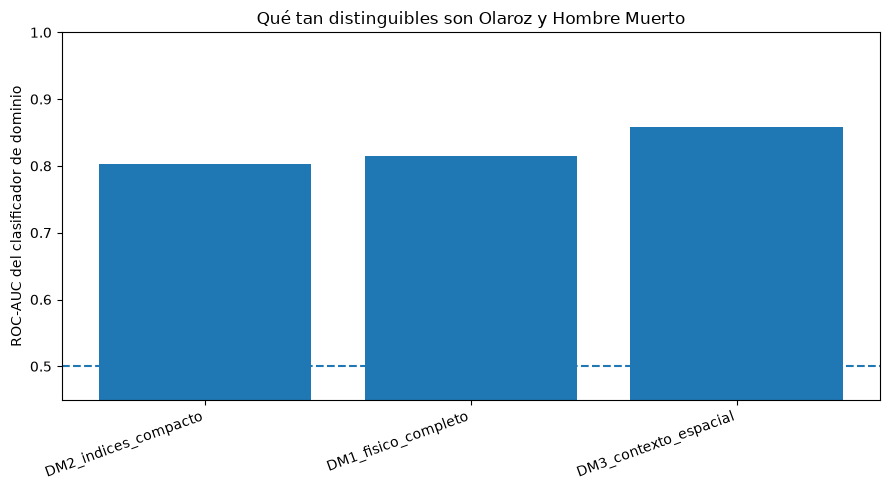

In [43]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    domain_classifier_report[
        "data_mart"
    ],
    domain_classifier_report[
        "domain_auc_mean"
    ],
)

plt.axhline(
    0.5,
    linestyle="--",
)

plt.ylim(
    0.45,
    1.0,
)

plt.ylabel(
    "ROC-AUC del clasificador de dominio"
)

plt.title(
    "Qué tan distinguibles son Olaroz y Hombre Muerto"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()
plt.show()

### Interpretación

- **AUC ≈ 0.50:** las features no permiten distinguir fácilmente los salares.
- **AUC claramente > 0.50:** existe domain shift detectable.
- **AUC cercana a 1:** los dominios son muy diferentes en ese espacio de features.

Para transferencia, una AUC menor puede ser deseable, **pero no alcanza**.

La evaluación definitiva vendrá después:

```text
Train Olaroz -> Test Hombre Muerto
Train Hombre Muerto -> Test Olaroz
```

con F1-macro y otras métricas de clasificación.

## 29. SMD final de los Data Marts

In [44]:
def smd_summary_for_mart(
    data: pd.DataFrame,
    features: list[str],
    mart_name: str,
) -> pd.DataFrame:

    report = (
        build_smd_report(
            data=data,
            feature_columns=features,
            domain_a=DOMAIN_A,
            domain_b=DOMAIN_B,
        )
    )

    report.insert(
        0,
        "data_mart",
        mart_name,
    )

    return report


smd_dm1 = (
    smd_summary_for_mart(
        data_mart_01,
        dm1_features,
        "DM1_fisico_completo",
    )
)

smd_dm2 = (
    smd_summary_for_mart(
        data_mart_02,
        dm2_features,
        "DM2_indices_compacto",
    )
)

smd_dm3 = (
    smd_summary_for_mart(
        data_mart_03,
        dm3_features,
        "DM3_contexto_espacial",
    )
)


smd_all_marts = pd.concat(
    [
        smd_dm1,
        smd_dm2,
        smd_dm3,
    ],
    ignore_index=True,
)


smd_mart_summary = (
    smd_all_marts
    .groupby(
        "data_mart"
    )
    .agg(
        mean_abs_smd=(
            "abs_smd",
            "mean",
        ),
        median_abs_smd=(
            "abs_smd",
            "median",
        ),
        max_abs_smd=(
            "abs_smd",
            "max",
        ),
    )
    .reset_index()
)


display(
    smd_mart_summary
)

,data_mart,mean_abs_smd,median_abs_smd,max_abs_smd
0,DM1_fisico_completo,0.178041,0.143115,0.420576
1,DM2_indices_compacto,0.188797,0.155462,0.420576
2,DM3_contexto_espacial,0.166177,0.121007,0.571755


## 30. Domain shift condicionado por clase

In [45]:
# Este análisis es muy importante:
#
# Compara, por ejemplo:
#
# salina en Olaroz
#     vs
# salina en Hombre Muerto
#
# De esta forma reducimos el riesgo de confundir cambio de
# dominio con cambio en la composición de clases.


domain_shift_by_class = (
    build_smd_report(
        data=df,
        feature_columns=dm1_features,
        domain_a=DOMAIN_A,
        domain_b=DOMAIN_B,
        class_column=TARGET_COL,
    )
)

display(
    domain_shift_by_class
    .groupby(
        "scope",
        as_index=False,
    )
    .agg(
        mean_abs_smd=(
            "abs_smd",
            "mean",
        ),
        median_abs_smd=(
            "abs_smd",
            "median",
        ),
        max_abs_smd=(
            "abs_smd",
            "max",
        ),
    )
)

,scope,mean_abs_smd,median_abs_smd,max_abs_smd
0,agua_humedad,0.452844,0.232750,1.217340
1,salina,0.519112,0.463563,1.174598
2,suelo_desnudo,1.313266,1.235256,1.809600
3,suelo_rocoso,0.580210,0.571282,1.306559


# 31. Validación final de los tres Data Marts

In [46]:
def validate_data_mart(
    data: pd.DataFrame,
    feature_columns: list[str],
    name: str,
) -> None:
    '''
    Controles mínimos antes de exportar.
    '''

    print(
        f"\nValidando {name}"
    )

    if data[
        ID_COL
    ].duplicated().any():

        raise ValueError(
            f"{name}: sample_id duplicados"
        )


    for required in [
        GROUP_COL,
        DOMAIN_COL,
        TARGET_COL,
    ]:

        if data[
            required
        ].isna().any():

            raise ValueError(
                f"{name}: nulos en "
                f"{required}"
            )


    numeric_features = (
        data[
            feature_columns
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    if not (
        numeric_features
        .notna()
        .all()
        .all()
    ):

        raise ValueError(
            f"{name}: existen NaN/inf "
            "en predictors"
        )


    print(
        "  muestras:",
        len(data),
    )

    print(
        "  polígonos:",
        data[
            GROUP_COL
        ].nunique(),
    )

    print(
        "  features:",
        len(
            feature_columns
        ),
    )

    print(
        "  ✓ OK"
    )


validate_data_mart(
    data_mart_01,
    dm1_features,
    "Data Mart 01",
)

validate_data_mart(
    data_mart_02,
    dm2_features,
    "Data Mart 02",
)

validate_data_mart(
    data_mart_03,
    dm3_features,
    "Data Mart 03",
)


Validando Data Mart 01
  muestras: 38621
  polígonos: 48
  features: 27
  ✓ OK

Validando Data Mart 02
  muestras: 38621
  polígonos: 48
  features: 17
  ✓ OK

Validando Data Mart 03
  muestras: 38621
  polígonos: 48
  features: 33
  ✓ OK


# 32. Diccionario de variables

In [47]:
def get_variable_role(
    column: str,
) -> str:

    if column == ID_COL:
        return "identifier"

    if column == GROUP_COL:
        return "group"

    if column == DOMAIN_COL:
        return "domain"

    if column == TARGET_COL:
        return "target"

    if column in [
        "x",
        "y",
        "lon",
        "lat",
    ]:
        return "absolute_spatial_metadata"

    if column.startswith(
        "spatial_"
    ):
        return "engineered_spatial_feature"

    if column.startswith(
        "spec_"
    ):
        return "spectral_band"

    if column.startswith(
        "feat_"
    ):
        return "spectral_index"

    if column.startswith(
        "eng_"
    ):
        return "engineered_spectral_feature"

    if column in [
        "confianza",
        "qa_valid_fraction",
        "qa_level",
        "sample_weight_equal_polygon",
        "n_outlier_features",
        "is_outlier_candidate",
    ]:
        return "quality_or_training_metadata"

    return "other"


dictionary_rows = []

for col in df.columns:

    role = get_variable_role(
        col
    )

    dictionary_rows.append(
        {
            "column": col,
            "dtype": str(
                df[col].dtype
            ),
            "role": role,
            "in_dm1": (
                col in dm1_features
            ),
            "in_dm2": (
                col in dm2_features
            ),
            "in_dm3": (
                col in dm3_features
            ),
        }
    )


data_dictionary = pd.DataFrame(
    dictionary_rows
)

display(
    data_dictionary
)

,column,dtype,role,in_dm1,in_dm2,in_dm3
0,sample_id,str,identifier,False,False,False
1,polygon_id,str,group,False,False,False
2,salar,str,domain,False,False,False
3,clase,str,target,False,False,False
4,confianza,int64,quality_or_training_metadata,False,False,False
5,x,float64,absolute_spatial_metadata,False,False,False
6,y,float64,absolute_spatial_metadata,False,False,False
7,lon,float64,absolute_spatial_metadata,False,False,False
8,lat,float64,absolute_spatial_metadata,False,False,False
9,spec_B04,float32,spectral_band,True,False,True


# 33. Reportes de calidad

In [48]:
class_report_final = (
    df
    .groupby(
        [
            DOMAIN_COL,
            TARGET_COL,
        ]
    )
    .agg(
        n_samples=(
            ID_COL,
            "size",
        ),
        n_polygons=(
            GROUP_COL,
            "nunique",
        ),
    )
    .reset_index()
)


polygon_report_final = (
    df
    .groupby(
        [
            GROUP_COL,
            DOMAIN_COL,
            TARGET_COL,
        ],
        as_index=False,
    )
    .agg(
        n_samples=(
            ID_COL,
            "size",
        ),
        mean_sample_weight=(
            "sample_weight_equal_polygon",
            "mean",
        ),
        outlier_candidates=(
            "is_outlier_candidate",
            "sum",
        ),
    )
)


quality_report = pd.DataFrame(
    {
        "metric": [
            "n_samples_raw",
            "n_samples_curated",
            "n_polygons",
            "n_domains",
            "n_classes",
            "n_raw_candidate_features",
            "n_exact_duplicate_features_removed",
            "n_constant_features_removed",
            "n_engineered_spectral_features",
            "n_engineered_spatial_features",
            "n_outlier_candidates",
        ],
        "value": [
            len(
                df_raw
            ),
            len(
                df
            ),
            df[
                GROUP_COL
            ].nunique(),
            df[
                DOMAIN_COL
            ].nunique(),
            df[
                TARGET_COL
            ].nunique(),
            len(
                raw_feature_cols
            ),
            len(
                features_to_drop
            ),
            len(
                constant_features
            ),
            len(
                engineered_spectral_cols
            ),
            len(
                engineered_spatial_cols
            ),
            int(
                df[
                    "is_outlier_candidate"
                ].sum()
            ),
        ],
    }
)


display(
    quality_report
)

,metric,value
0,n_samples_raw,38621
1,n_samples_curated,38621
2,n_polygons,48
3,n_domains,2
4,n_classes,4
5,n_raw_candidate_features,25
6,n_exact_duplicate_features_removed,10
7,n_constant_features_removed,0
8,n_engineered_spectral_features,12
9,n_engineered_spatial_features,6


# 34. Exportación

Parquet es el formato recomendado para los próximos notebooks.

CSV se exporta por compatibilidad y facilidad de inspección.

In [49]:
def export_dataset(
    data: pd.DataFrame,
    stem: str,
) -> dict:
    '''
    Exporta CSV siempre y Parquet si pyarrow/fastparquet está
    disponible.
    '''

    csv_path = (
        OUTPUT_DIR
        / f"{stem}.csv"
    )

    parquet_path = (
        OUTPUT_DIR
        / f"{stem}.parquet"
    )


    data.to_csv(
        csv_path,
        index=False,
    )


    parquet_ok = False

    try:

        data.to_parquet(
            parquet_path,
            index=False,
        )

        parquet_ok = True

    except Exception as exc:

        print(
            f"No se pudo exportar "
            f"{parquet_path.name}:"
        )

        print(
            exc
        )


    return {
        "csv": str(
            csv_path
        ),
        "parquet": (
            str(
                parquet_path
            )
            if parquet_ok
            else None
        ),
    }

In [52]:
exports = {}


# Data Master curado


exports[
    "data_master_curado"
] = export_dataset(
    data=df,
    stem="data_master_curado",
)


# Tres Data Marts

exports[
    "data_mart_01_fisico_completo"
] = export_dataset(
    data=data_mart_01,
    stem="data_mart_01_fisico_completo",
)


exports[
    "data_mart_02_indices_compacto"
] = export_dataset(
    data=data_mart_02,
    stem="data_mart_02_indices_compacto",
)


exports[
    "data_mart_03_contexto_espacial"
] = export_dataset(
    data=data_mart_03,
    stem="data_mart_03_contexto_espacial",
)


print(
    "✓ DataFrames exportados"
)

✓ DataFrames exportados


In [53]:
# Exportar reportes

quality_report.to_csv(
    OUTPUT_DIR
    / "reporte_calidad.csv",
    index=False,
)

polygon_report_final.to_csv(
    OUTPUT_DIR
    / "reporte_poligonos.csv",
    index=False,
)

class_report_final.to_csv(
    OUTPUT_DIR
    / "reporte_clases.csv",
    index=False,
)

smd_global_raw.to_csv(
    OUTPUT_DIR
    / "reporte_domain_shift_global.csv",
    index=False,
)

domain_shift_by_class.to_csv(
    OUTPUT_DIR
    / "reporte_domain_shift_por_clase.csv",
    index=False,
)

domain_classifier_report.to_csv(
    OUTPUT_DIR
    / "reporte_domain_classifier.csv",
    index=False,
)

data_dictionary.to_csv(
    OUTPUT_DIR
    / "diccionario_variables.csv",
    index=False,
)

# 35. Metadata reproducible

In [54]:
metadata_out = {
    "dataset_name": (
        "salares_ml_curated_datamarts"
    ),
    "source_metadata": (
        source_metadata
    ),
    "random_state": (
        RANDOM_STATE
    ),
    "id_column": (
        ID_COL
    ),
    "group_column": (
        GROUP_COL
    ),
    "domain_column": (
        DOMAIN_COL
    ),
    "target_column": (
        TARGET_COL
    ),
    "domains": sorted(
        df[
            DOMAIN_COL
        ]
        .unique()
        .tolist()
    ),
    "classes": sorted(
        df[
            TARGET_COL
        ]
        .unique()
        .tolist()
    ),
    "n_samples": int(
        len(df)
    ),
    "n_polygons": int(
        df[
            GROUP_COL
        ]
        .nunique()
    ),
    "removed_constant_features": (
        constant_features
    ),
    "removed_exact_duplicate_features": (
        features_to_drop
    ),
    "engineered_spectral_features": (
        engineered_spectral_cols
    ),
    "engineered_spatial_features": (
        engineered_spatial_cols
    ),
    "data_marts": {
        "DM1_fisico_completo": {
            "purpose": (
                "Baseline principal con bandas, "
                "indices y features fisicas."
            ),
            "features": (
                dm1_features
            ),
        },
        "DM2_indices_compacto": {
            "purpose": (
                "Representacion compacta para "
                "comparar parsimonia y transferencia."
            ),
            "features": (
                dm2_features
            ),
        },
        "DM3_contexto_espacial": {
            "purpose": (
                "Ablation experiment agregando "
                "contexto espacial relativo."
            ),
            "features": (
                dm3_features
            ),
        },
    },
    "methodological_rules": {
        "split_unit": (
            "polygon_id"
        ),
        "never_random_pixel_split": (
            True
        ),
        "use_absolute_coordinates_as_predictors": (
            False
        ),
        "use_domain_label_as_predictor": (
            False
        ),
        "outlier_policy": (
            "flag_only_no_automatic_deletion"
        ),
        "cross_domain_evaluation": [
            "olaroz -> hombre_muerto",
            "hombre_muerto -> olaroz",
        ],
    },
    "exports": (
        exports
    ),
}


metadata_output_path = (
    OUTPUT_DIR
    / "metadata_datamarts.json"
)


with open(
    metadata_output_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metadata_out,
        file,
        ensure_ascii=False,
        indent=4,
    )


print(
    "✓ Metadata exportada:"
)

print(
    metadata_output_path.resolve()
)

✓ Metadata exportada:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_datamarts\metadata_datamarts.json


# 36. Resumen final

Al finalizar este notebook quedan tres alternativas para los experimentos posteriores:

| Data Mart | Propósito |
|---|---|
| **DM1 Físico completo** | Baseline científico principal |
| **DM2 Índices compacto** | Evaluar parsimonia y posible robustez |
| **DM3 Contexto espacial** | Medir si el contexto espacial ayuda o perjudica transferencia |

---

# Siguiente Notebook — Aprendizaje No Supervisado

El Notebook 02 debería comparar los tres Data Marts con:

```text
StandardScaler
PCA
KMeans
Silhouette Score
Davies-Bouldin
Calinski-Harabasz
ARI
NMI
estabilidad por dominio
```

La clase real se utilizará **solo después de formar los clusters**, para interpretar el resultado.

---

# Notebook 03 — Aprendizaje Supervisado

Para cada Data Mart:

```text
DummyClassifier
LogisticRegression
RandomForest
ExtraTrees
HistGradientBoosting
```

con:

```text
StratifiedGroupKFold / GroupKFold
groups = polygon_id
```

Métricas principales:

```text
F1-macro
Balanced Accuracy
Precision / Recall por clase
Matriz de confusión
```

---

# Transferencia de dominio

Finalmente:

```text
Experimento A
Train: Olaroz
Test: Hombre Muerto

Experimento B
Train: Hombre Muerto
Test: Olaroz
```

y comparar contra validación **in-domain**.

Una medida simple de degradación será:

```text
Delta F1 =
F1_in_domain
-
F1_cross_domain
```

La combinación de:

- SMD;
- clasificador de dominio;
- desempeño in-domain;
- desempeño cross-domain;

permitirá evaluar de manera mucho más rigurosa la existencia de transferencia.

In [55]:
print(
    "PIPELINE 01 FINALIZADO"
)

print(
    "=" * 70
)

print(
    "\nData Master:"
)

print(
    exports[
        "data_master_curado"
    ]
)

print(
    "\nData Mart 01:"
)

print(
    exports[
        "data_mart_01_fisico_completo"
    ]
)

print(
    "\nData Mart 02:"
)

print(
    exports[
        "data_mart_02_indices_compacto"
    ]
)

print(
    "\nData Mart 03:"
)

print(
    exports[
        "data_mart_03_contexto_espacial"
    ]
)

print(
    "\nReportes disponibles en:"
)

print(
    OUTPUT_DIR.resolve()
)

PIPELINE 01 FINALIZADO

Data Master:
{'csv': 'outputs_datamarts\\data_master_curado.csv', 'parquet': 'outputs_datamarts\\data_master_curado.parquet'}

Data Mart 01:
{'csv': 'outputs_datamarts\\data_mart_01_fisico_completo.csv', 'parquet': 'outputs_datamarts\\data_mart_01_fisico_completo.parquet'}

Data Mart 02:
{'csv': 'outputs_datamarts\\data_mart_02_indices_compacto.csv', 'parquet': 'outputs_datamarts\\data_mart_02_indices_compacto.parquet'}

Data Mart 03:
{'csv': 'outputs_datamarts\\data_mart_03_contexto_espacial.csv', 'parquet': 'outputs_datamarts\\data_mart_03_contexto_espacial.parquet'}

Reportes disponibles en:
C:\Users\pablonicolasr\Desktop\pablonicolas\educacion_formal\mentodatos2026\repo\mentodatos_pdis\ml_03\parte2\outputs_datamarts
